# Time evolution with dense matrices — propagators, ODE solvers and Trotterization

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 2 — Quantum many-body spin systems with dense matrices*

## 1. Introduction and motivation

In the previous notebook we learned how to write down a chain of $N$ interacting spins-1/2, how to build its Hamiltonian as a
$2^N\times2^N$ matrix, and how to find its ground state. That is *statics*. This notebook is about **dynamics**: we prepare the chain in
some simple state $|\psi_0\rangle$, let it evolve under its Hamiltonian $H$, and ask what happens,

$$ i\,\frac{d}{dt}|\psi(t)\rangle = H\,|\psi(t)\rangle ,\qquad |\psi(0)\rangle=|\psi_0\rangle \qquad(\hbar=1). $$

**Experimental context.** For most of the twentieth century this question was academic: a magnet in a laboratory is never isolated well enough
for its wave function to evolve coherently. That has changed. Ultracold atoms in optical lattices, chains of trapped ions, arrays of
Rydberg atoms held in optical tweezers and superconducting circuits are *isolated, controllable spin chains*: one prepares a product state,
suddenly switches on a Hamiltonian (a **quantum quench**) and photographs the spins after a time $t$. Such experiments watch order
melt, correlations spread with a finite velocity (a "light cone"), and local observables of an isolated system relax to stationary values — or fail to (reviews: Polkovnikov *et al.* 2011; Heyl 2018). Interpreting them, and
designing the next ones, requires solving the Schrödinger equation for many interacting particles on a computer. It is also the basic
task a future quantum computer is expected to do better than we can; to appreciate that claim one should first understand how hard the
task is classically, and why.

**What we will do.** We stay with the *textbook* representation of notebook 03: states are vectors of length $2^N$ and operators
are dense $2^N\times2^N$ matrices. Within that setting we go through everything that a practitioner takes for granted about time evolution:

1. **Section 2** — we rebuild the small dense toolbox of notebook 03 (`site_operator`, `build_hamiltonian_dense`), so that this notebook runs on its own.
2. **Sections 3–4** — the formal solution $|\psi(t)\rangle=e^{-iHt}|\psi_0\rangle$; the propagator from an **eigendecomposition**; what must be
   conserved (norm, energy) and how to test it.
3. **Section 5** — the **matrix exponential** `expm`: why summing the Taylor series is a bad idea and what libraries do instead.
4. **Section 6** — treating the Schrödinger equation as an ordinary differential equation: the **Euler** method fails (we predict
   *and* measure the blow-up of the norm), **RK4** works much better but comes with a step-size rule $dt\,\|H\|\le2\sqrt2$ that tightens as the chain
   grows — and we discuss why physicists nevertheless prefer *unitary* integrators.
5. **Section 7, the centrepiece — Trotterization of the propagator.** Exponentials of non-commuting matrices, the Baker–Campbell–Hausdorff formula
   derived to the order we need, first-order (Lie–Trotter) and second-order (Strang) splitting, the even/odd decomposition of a chain,
   measured error scaling against $dt$ with reference slopes, and error growth in time.
6. **Section 8** — physics: a quench in the transverse-field Ising chain. Magnetisation dynamics, the light cone of correlations,
   the Loschmidt echo.
7. **Section 9** — the cost of each method in memory and time, why *every* method of this notebook dies around $N\approx 12$–$14$ spins, and
   which single observation will let us escape in the next notebook.

### What you will learn

*Physics*

* The propagator $U(t)=e^{-iHt}$, its unitarity and group property, conservation of energy; stationary states and phases.
* What a quantum quench is; how local magnetisation relaxes, why correlations spread inside a light cone, what the Loschmidt echo measures.

*Numerical methods*

* Three routes to $e^{-iHt}|\psi\rangle$: eigendecomposition, matrix exponential (scaling and squaring), ODE integration (Euler, RK4).
* Stability and order of accuracy of an integrator; how to *measure* the order on a log–log plot; the explicit step-size rule $dt\,\|H\|\le2\sqrt2$ for RK4 and why it tightens with $N$.
* Trotter–Suzuki splitting: local versus global error, the role of commutators, symmetric (Strang) splitting, why splitting is exactly unitary.
* Cost accounting: $O(8^N)$ time and $O(4^N)$ memory of dense methods.

*Implementation practice*

* Validating every solver against an independent one, and against conservation laws, with `assert`s.
* `jax.jit` for whole time steps, `jax.lax.scan` for time loops, `jax.vmap` over a time grid, `jax.scipy.linalg.expm`.
* Timing JAX code (`block_until_ready`, compile time versus run time).

### Prerequisites

* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, timing.
* [03 — Quantum many-body spin systems](03_quantum_many_body_spin_systems.ipynb): tensor products, `site_operator`, dense Hamiltonians, the
  transverse-field Ising and XXZ chains, exact diagonalisation with `eigh`.

One semester of quantum mechanics (Schrödinger equation, spin-1/2, Pauli matrices) is assumed; nothing else. We set $\hbar=1$ throughout,
so energies are frequencies and time is measured in units of the inverse coupling $1/J$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. The dense toolbox of notebook 03

### 2.1 Conventions

We use exactly the conventions of notebook 03, which are the conventions of the whole course:

| symbol | meaning |
|---|---|
| $N$ | number of spins-1/2, labelled $j=0,1,\dots,N-1$ from left to right |
| $X,Y,Z$ | Pauli matrices; $\vert 0\rangle=(1,0)^T=\vert{\uparrow}\rangle$ is the $+1$ eigenstate of $Z$, $\vert 1\rangle=(0,1)^T=\vert{\downarrow}\rangle$ |
| $\vert s_0s_1\dots s_{N-1}\rangle$ | basis state with bits $s_j\in\{0,1\}$; its position in the state vector is the flat index $i=\sum_j s_j\,2^{N-1-j}$ (spin 0 = most significant bit) |
| $O_j$ | operator $O$ acting on spin $j$: $\mathbb 1\otimes\dots\otimes O\otimes\dots\otimes\mathbb 1$ with $O$ as the $j$-th Kronecker factor |
| $D=2^N$ | dimension of the Hilbert space |

The family of Hamiltonians is written in the **Pauli convention** (no factors of $1/2$):

$$ H=\sum_{\langle i,j\rangle}\big(J_{xx}X_iX_j+J_{yy}Y_iY_j+J_{zz}Z_iZ_j\big)+\sum_{i}\big(h_xX_i+h_yY_i+h_zZ_i\big), \tag{1}$$

where $\langle i,j\rangle$ runs over nearest neighbours $(j,j+1)$ of an open chain (plus the bond $(N-1,0)$ if `periodic=True`).
Special cases: the **transverse-field Ising model** (TFIM) $H=-J\sum_jZ_jZ_{j+1}-h\sum_jX_j$, i.e. $J_{zz}=-J$, $h_x=-h$; the
**Heisenberg/XXZ chain** $J_{xx}=J_{yy}=J$, $J_{zz}=\Delta J$.

### 2.2 From formula to code

* `site_operator(op, j, N)` is the Kronecker chain $\mathbb 1\otimes\dots\otimes O\otimes\dots\otimes\mathbb 1$: start from the $1\times1$ matrix $(1)$ and
  multiply from the right with `jnp.kron`, inserting `op` at position `j` and the $2\times2$ identity elsewhere. Because spin 0 is the leftmost factor,
  it is the most significant bit of the flat index — consistent with the table above.
* `two_site_operator(h2, j, N)` embeds a $4\times4$ matrix acting on the neighbouring spins $(j,j+1)$:
  $\mathbb 1_{2^j}\otimes h_2\otimes\mathbb 1_{2^{N-j-2}}$. For a product $h_2=A\otimes B$ it equals `site_operator(A,j,N) @ site_operator(B,j+1,N)`
  (we check this), but it needs no large matrix product. We will need it again for Trotterization, where $h_2$ is *not* a simple product.
* `build_hamiltonian_dense` adds up all terms of Eq. (1).

In [2]:
from jax.scipy.linalg import expm          # dense matrix exponential (Section 5)

# ==============================================================================
# STEP 1: Pauli matrices and embedded operators (same names and conventions as notebook 03)
# ==============================================================================
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)

# colour-blind-friendly palette (Okabe-Ito) used in all figures
C_BLUE, C_ORANGE, C_GREEN, C_PINK, C_YELLOW, C_SKY = "#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"


def site_operator(op, j, N):
    """Single-site operator `op` (2x2) acting on spin j of an N-spin chain, as a dense 2^N x 2^N matrix.

    MATH            O_j = 1 (x) ... (x) 1 (x) O (x) 1 (x) ... (x) 1        (O is the j-th Kronecker factor, j = 0..N-1)
    IMPLEMENTATION  a chain of N `jnp.kron` products starting from the 1x1 matrix (1).
                    Spin 0 is the LEFTMOST factor = most significant bit of the flat index.
    COST            4^N numbers of memory -- for an object that is defined by 4 numbers.  Remember this (Section 9).
    """
    out = jnp.eye(1, dtype=CDTYPE)
    for k in range(N):
        out = jnp.kron(out, op if k == j else I2)
    return out


def two_site_operator(h2, j, N):
    """Two-site operator `h2` (4x4, basis |00>,|01>,|10>,|11> of spins j, j+1) embedded in the N-spin space.

    MATH            h_{j,j+1} = 1_{2^j} (x) h2 (x) 1_{2^(N-j-2)}
    IMPLEMENTATION  two `jnp.kron` calls with identity blocks; the left spin of the pair (j) is the left
                    Kronecker factor of h2, e.g. h2 = kron(Z, Z) or kron(X, 1).
    """
    left = jnp.eye(2 ** j, dtype=CDTYPE)
    right = jnp.eye(2 ** (N - j - 2), dtype=CDTYPE)
    return jnp.kron(jnp.kron(left, jnp.asarray(h2, dtype=CDTYPE)), right)


def build_hamiltonian_dense(N, Jxx, Jyy, Jzz, hx, hy, hz, periodic=False):
    """Dense 2^N x 2^N Hamiltonian of a spin-1/2 chain in the Pauli convention, Eq. (1):

    MATH            H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
                    TFIM: Jzz = -J, hx = -h.      XXZ: Jxx = Jyy = J, Jzz = Delta*J.
    IMPLEMENTATION  bonds (j, j+1) via `two_site_operator`; the periodic bond (N-1, 0) is not a block of
                    neighbouring Kronecker factors, so it is built as a product of two site operators.
    COST            O(N 4^N) operations, O(4^N) memory.
    """
    D = 2 ** N
    H = jnp.zeros((D, D), dtype=CDTYPE)
    h2 = Jxx * jnp.kron(X, X) + Jyy * jnp.kron(Y, Y) + Jzz * jnp.kron(Z, Z)      # 4x4 bond matrix
    for j in range(N - 1):
        H = H + two_site_operator(h2, j, N)
    if periodic and N > 2:
        for Jc, P in ((Jxx, X), (Jyy, Y), (Jzz, Z)):
            if Jc != 0:
                H = H + Jc * site_operator(P, N - 1, N) @ site_operator(P, 0, N)
    h1 = hx * X + hy * Y + hz * Z                                               # 2x2 field matrix
    if hx != 0 or hy != 0 or hz != 0:
        for j in range(N):
            H = H + site_operator(h1, j, N)
    return H


def max_abs(A):
    """Largest absolute entry of an array, as a Python float (our standard error measure in checkpoints)."""
    return float(jnp.max(jnp.abs(A)))

**Checkpoint.** Never trust a builder you have not tested. Three independent checks: (i) for $N=2$ the TFIM matrix can be written down by hand,
(ii) the block embedding agrees with the product of two site operators, (iii) $H$ is Hermitian for a generic set of couplings, open and periodic.

In [3]:
# ==============================================================================
# CHECKPOINT 1: the Hamiltonian builder
# ==============================================================================
# (i) N = 2 TFIM by hand:  H = -J Z(x)Z - h (X(x)1 + 1(x)X),  basis |00>,|01>,|10>,|11>
J_, h_ = 1.0, 0.7
H2_hand = jnp.array([[-J_, -h_, -h_, 0.0],
                     [-h_, +J_, 0.0, -h_],
                     [-h_, 0.0, +J_, -h_],
                     [0.0, -h_, -h_, -J_]], dtype=CDTYPE)
err_hand = max_abs(build_hamiltonian_dense(2, 0.0, 0.0, -J_, -h_, 0.0, 0.0) - H2_hand)

# (ii) block embedding == product of site operators
err_embed = max_abs(two_site_operator(jnp.kron(X, Y), 1, 4) - site_operator(X, 1, 4) @ site_operator(Y, 2, 4))

# (iii) Hermiticity for generic couplings
errs_herm = []
for periodic in (False, True):
    Hg = build_hamiltonian_dense(5, 0.3, -1.1, 0.8, 0.5, -0.4, 0.9, periodic=periodic)
    errs_herm.append(max_abs(Hg - Hg.conj().T))

print(f"(i)   N=2 TFIM vs hand-written matrix : {err_hand:.1e}")
print(f"(ii)  block embedding vs site product : {err_embed:.1e}")
print(f"(iii) ||H - H^dag||_max  open/periodic : {errs_herm[0]:.1e} / {errs_herm[1]:.1e}")
assert max(err_hand, err_embed, *errs_herm) < TOL

(i)   N=2 TFIM vs hand-written matrix : 0.0e+00
(ii)  block embedding vs site product : 0.0e+00
(iii) ||H - H^dag||_max  open/periodic : 0.0e+00 / 0.0e+00


All three errors are exactly zero (sums of a few numbers of order one incur no round-off here). The builder is safe to use.

### 2.3 States and observables

* A **basis state** $|s_0\dots s_{N-1}\rangle$ is a vector with a single 1 at the flat index $i=\sum_js_j2^{N-1-j}$. The fully polarised state
  $|{\uparrow\uparrow\cdots\uparrow}\rangle=|00\cdots0\rangle$ is therefore the unit vector $e_0$.
* A general **expectation value** is $\langle O\rangle=\langle\psi|O|\psi\rangle$ = `vdot(psi, O @ psi)` (`jnp.vdot` complex-conjugates its first argument).
* For observables that are **diagonal in the computational basis** ($Z_j$, $Z_iZ_j$, …) no matrix is needed. In the basis state $|s\rangle$ the
  operator $Z_j$ has the value $z_j(s)=(-1)^{s_j}=1-2s_j$, hence

  $$\langle Z_j\rangle=\sum_s|\psi_s|^2\,z_j(s),\qquad \langle Z_iZ_j\rangle=\sum_s|\psi_s|^2\,z_i(s)z_j(s).$$

  We store all values $z_j(s)$ once in a table of shape $(2^N,N)$, extracted from the bits of the flat index with shifts: $s_j$ = `(i >> (N-1-j)) & 1`.
  Then *all* $N$ magnetisations are one matrix–vector product `probs @ ztab`.

In [4]:
# ==============================================================================
# STEP 2: states and observables
# ==============================================================================
def basis_state(bits):
    """Computational basis state |s_0 s_1 ... s_{N-1}> as a flat vector of length 2^N.

    MATH   flat index  i = sum_j s_j 2^(N-1-j)   (spin 0 = most significant bit);  0 = up, 1 = down.
    JAX    arrays are immutable: `.at[i].set(1)` returns an updated copy (see notebook 01).
    """
    N = len(bits)
    i = sum(int(s) << (N - 1 - j) for j, s in enumerate(bits))
    return jnp.zeros(2 ** N, dtype=CDTYPE).at[i].set(1.0)


def expectation(psi, O):
    """<psi|O|psi> for a dense Hermitian matrix O (real part; the imaginary part is round-off)."""
    return jnp.real(jnp.vdot(psi, O @ psi))


def z_table(N):
    """Table z[i, j] = eigenvalue (+1/-1) of Z_j in the basis state with flat index i.  Shape (2^N, N).

    MATH   z_j(s) = 1 - 2 s_j,   s_j = (i >> (N-1-j)) & 1
    USE    <Z_j> = sum_i |psi_i|^2 z[i, j]  ->  all N magnetisations at once:  probs @ z_table(N).
    """
    i = jnp.arange(2 ** N)
    bits = (i[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1
    return (1 - 2 * bits).astype(RDTYPE)


# quick self-test on a random normalised state of 4 spins
key = jax.random.PRNGKey(0)
k1, k2 = jax.random.split(key)
v = jax.random.normal(k1, (16,)) + 1j * jax.random.normal(k2, (16,))
v = (v / jnp.linalg.norm(v)).astype(CDTYPE)
mz_matrix = jnp.array([expectation(v, site_operator(Z, j, 4)) for j in range(4)])
mz_table = (jnp.abs(v) ** 2) @ z_table(4)
print("<Z_j> from dense matrices :", np.round(np.asarray(mz_matrix), 6))
print("<Z_j> from the z-table    :", np.round(np.asarray(mz_table), 6))
assert max_abs(mz_matrix - mz_table) < TOL

<Z_j> from dense matrices : [0.134798 0.60606  0.078249 0.068424]
<Z_j> from the z-table    : [0.134798 0.60606  0.078249 0.068424]


The two routes agree. The second one never touched a $2^N\times2^N$ matrix — a first hint of the theme that will take over in notebook 05.

> **JAX practice.** Randomness in JAX is explicit: a key (`PRNGKey(0)`) is split into independent sub-keys, and the same key always gives the same
> numbers. The notebook is therefore reproducible bit by bit. See [notebook 01](../ch01_computational_toolbox/01_jax_from_scratch.ipynb).

## 3. The Schrödinger equation and the propagator

### 3.1 Formal solution

For a time-independent $H$ the Schrödinger equation $i\,\partial_t|\psi\rangle=H|\psi\rangle$ is a *linear* system of $D=2^N$ coupled ordinary
differential equations with constant coefficients. Exactly as for the scalar equation $\dot y=ay\Rightarrow y(t)=e^{at}y(0)$, its solution is

$$ |\psi(t)\rangle = U(t)\,|\psi_0\rangle,\qquad U(t)=e^{-iHt}\equiv\sum_{k=0}^{\infty}\frac{(-iHt)^k}{k!}. \tag{2}$$

*Proof.* Differentiate the series term by term: $\frac{d}{dt}U(t)=\sum_{k\ge1}\frac{(-iH)^k t^{k-1}}{(k-1)!}=-iH\,U(t)$, and $U(0)=\mathbb 1$. $\square$

The matrix $U(t)$ is called the **propagator** (or time-evolution operator; Sakurai and Napolitano, §2.1). Three properties follow directly from $H=H^\dagger$ and will serve
as our test suite for every numerical method:

1. **Unitarity.** $U(t)^\dagger=e^{+iH^\dagger t}=e^{+iHt}=U(-t)=U(t)^{-1}$. Consequently the norm is conserved,
   $\langle\psi(t)|\psi(t)\rangle=\langle\psi_0|U^\dagger U|\psi_0\rangle=1$: probability does not leak.
2. **Group property.** $U(t_1+t_2)=U(t_1)U(t_2)$, because $Ht_1$ and $Ht_2$ commute (Section 7.1 shows that commuting exponents simply add).
   Evolving for $t$ in one go or in $n$ small steps of $dt=t/n$ is the same thing: $U(t)=U(dt)^n$.
3. **Energy conservation.** $[H,U(t)]=0$ since $U$ is a power series in $H$; hence
   $\langle H\rangle_t=\langle\psi_0|U^\dagger HU|\psi_0\rangle=\langle\psi_0|H|\psi_0\rangle$. More generally, the expectation value of *any* operator that
   commutes with $H$ is constant.

The whole notebook is about one question: **how do we compute the action of $e^{-iHt}$ on a vector when $H$ is a big matrix?**

## 4. Method 1 — the propagator from an eigendecomposition

### 4.1 Derivation

Let $H|n\rangle=E_n|n\rangle$ with orthonormal eigenvectors $|n\rangle$, $n=0,\dots,D-1$. Collect the eigenvectors as the columns of a unitary matrix $V$ and
the eigenvalues in a diagonal matrix $E$; then $H=VEV^\dagger$. Powers are easy, $H^k=VE^kV^\dagger$ (all inner $V^\dagger V=\mathbb 1$ cancel), so the series (2) gives

$$ U(t)=\sum_k\frac{(-it)^k}{k!}VE^kV^\dagger=V\,e^{-iEt}\,V^\dagger,\qquad e^{-iEt}={\rm diag}\big(e^{-iE_0t},\dots,e^{-iE_{D-1}t}\big). \tag{3}$$

In words — this is the recipe you know from the QM course:

1. expand the initial state in energy eigenstates, $c_n=\langle n|\psi_0\rangle$, i.e. $c=V^\dagger\psi_0$;
2. every coefficient just rotates its phase, $c_n(t)=e^{-iE_nt}c_n$;
3. go back to the original basis, $\psi(t)=V\,c(t)$.

$$ |\psi(t)\rangle=\sum_n e^{-iE_nt}\,\langle n|\psi_0\rangle\,|n\rangle. \tag{4}$$

Once $H$ is diagonalised (cost $O(D^3)=O(8^N)$, paid once), the state at **any** time $t$ — tomorrow or in a billion years — costs two matrix–vector
products, $O(D^2)$, and carries no time-step error whatsoever. This is why exact diagonalisation (ED) is the reference method for small systems.

### 4.2 From formula to code

* `diagonalize(H)` = `jnp.linalg.eigh` (for Hermitian matrices, algorithms in *Numerical Recipes*, Ch. 11; returns real ascending eigenvalues `E` of shape `(D,)` and `V` of shape `(D, D)` whose
  *columns* are eigenvectors).
* `evolve_eigh` is Eq. (4) literally: `V @ (exp(-1j*E*t) * (V^dag @ psi0))`. The product `phase * c` is element-wise (a diagonal matrix times a vector).
* `propagator_eigh` builds the full matrix of Eq. (3). The idiom `(V * phase) @ V^dag` multiplies *column* $n$ of $V$ by `phase[n]` through broadcasting —
  that is $V\,{\rm diag}({\rm phase})$ without ever forming the diagonal matrix.
* For a whole **time grid** `ts` of shape `(T,)` we want all states at once. `jnp.outer(ts, E)` has shape `(T, D)`; multiplying by `c` broadcasts over
  the time axis; one matrix product with `V.T` maps every row back to the original basis: `states[k] = V @ c(t_k)`, shape `(T, D)`.

In [5]:
# ==============================================================================
# STEP 3: exact evolution via the eigendecomposition  H = V E V^dag
# ==============================================================================
def diagonalize(H):
    """Full eigendecomposition of a Hermitian matrix:  H = V diag(E) V^dag.

    Returns E (D,) real ascending and V (D, D) with eigenvectors as COLUMNS.   COST  O(D^3) = O(8^N).
    """
    return jnp.linalg.eigh(H)


def propagator_eigh(E, V, t):
    """U(t) = V exp(-i E t) V^dag  as a dense D x D matrix, Eq. (3).

    IMPLEMENTATION  `V * phase` scales column n of V by phase[n] (broadcasting) = V @ diag(phase).
    """
    return (V * jnp.exp(-1j * E * t)) @ V.conj().T


def evolve_eigh(E, V, psi0, t):
    """|psi(t)> = V exp(-i E t) V^dag |psi0>, Eq. (4): expand in eigenstates, rotate phases, transform back.

    COST  O(D^2) per time, NO time-step error: t may be arbitrarily large.
    """
    c = V.conj().T @ psi0                       # c_n = <n|psi0>
    return V @ (jnp.exp(-1j * E * t) * c)       # sum_n e^{-i E_n t} c_n |n>


@jax.jit
def evolve_eigh_many(E, V, psi0, ts):
    """States on a whole time grid at once.  ts: (T,)  ->  states: (T, D),  states[k] = |psi(ts[k])>.

    IMPLEMENTATION  phases = exp(-i outer(ts, E)) has shape (T, D); `phases * c` broadcasts c over the T rows;
                    `(...) @ V.T` applies V to every row:  out[k, i] = sum_n V[i, n] c_n(t_k).
    JAX             jit-compiled: the broadcast, the exponential and the matmul are fused into one XLA program.
    """
    c = V.conj().T @ psi0
    return (jnp.exp(-1j * jnp.outer(ts, E)) * c[None, :]) @ V.T

### 4.3 Checkpoint on a problem with a known answer: one spin in a field

A single spin with $H=h_xX$, prepared in $|{\uparrow}\rangle$. Since $X^2=\mathbb 1$, the exponential series splits into even and odd powers,

$$ e^{-ih_xtX}=\sum_{k\ {\rm even}}\frac{(-ih_xt)^k}{k!}\mathbb 1+\sum_{k\ {\rm odd}}\frac{(-ih_xt)^k}{k!}X=\cos(h_xt)\,\mathbb 1-i\sin(h_xt)\,X, $$

so $|\psi(t)\rangle=\cos(h_xt)|{\uparrow}\rangle-i\sin(h_xt)|{\downarrow}\rangle$ and $\langle Z\rangle_t=\cos^2(h_xt)-\sin^2(h_xt)=\cos(2h_xt)$: **Larmor precession**
at the angular frequency $2h_x$ — the level splitting of $H$, as it must be. The same code that will evolve ten spins must reproduce this.

In [6]:
# ==============================================================================
# CHECKPOINT 2: Larmor precession of a single spin,  <Z>(t) = cos(2 hx t)
# ==============================================================================
hx_1 = 0.8
H_1 = build_hamiltonian_dense(1, 0.0, 0.0, 0.0, hx_1, 0.0, 0.0)          # = hx X
E_1, V_1 = diagonalize(H_1)
ts_1 = jnp.linspace(0.0, 10.0, 201)
states_1 = evolve_eigh_many(E_1, V_1, basis_state([0]), ts_1)             # (T, 2)
z_numeric = (jnp.abs(states_1) ** 2) @ z_table(1)[:, 0]
err_larmor = max_abs(z_numeric - jnp.cos(2 * hx_1 * ts_1))
print(f"eigenvalues of H = hx X : {np.asarray(E_1)}   (expected -hx, +hx = {-hx_1}, {hx_1})")
print(f"max |<Z>(t) - cos(2 hx t)| on t in [0, 10] : {err_larmor:.1e}")
assert err_larmor < TOL

eigenvalues of H = hx X : [-0.8  0.8]   (expected -hx, +hx = -0.8, 0.8)
max |<Z>(t) - cos(2 hx t)| on t in [0, 10] : 5.6e-16


Machine precision at all times: no time step, no accumulation of error.

### 4.4 The working example of this notebook, and the checkpoints every propagator must pass

From now on our laboratory is the **transverse-field Ising chain** $H=-J\sum_jZ_jZ_{j+1}-h\sum_jX_j$ with $N=8$ spins ($D=256$: small enough that every dense
operation is instantaneous, large enough to be a genuine many-body problem), started from $|{\uparrow\uparrow\cdots\uparrow}\rangle$. For $h=0$ this state is an
eigenstate (one of the two ferromagnetic ground states) and nothing would happen; the transverse field flips spins and sets things in motion.

In [7]:
# ==============================================================================
# PARAMETERS of the working example (change them and re-run the notebook)
# ==============================================================================
N = 8             # number of spins  (D = 2^N = 256)
J = 1.0           # Ising coupling: sets the unit of energy, 1/J the unit of time
h = 1.0           # transverse field (h = J is the quantum critical point of the infinite chain)
T_FINAL = 10.0    # final time, in units of 1/J

H = build_hamiltonian_dense(N, 0.0, 0.0, -J, -h, 0.0, 0.0)        # TFIM: Jzz = -J, hx = -h
psi0 = basis_state([0] * N)                                       # |up up ... up>
ZTAB = z_table(N)

t0 = time.perf_counter()
E, V = diagonalize(H)
E.block_until_ready()
print(f"eigh of the {2**N} x {2**N} Hamiltonian: {time.perf_counter() - t0:.2f} s   (includes JAX compilation/dispatch overhead)")
print(f"spectrum: E_min = {float(E[0]):.4f},  E_max = {float(E[-1]):.4f},  spectral width W = {float(E[-1] - E[0]):.4f}")
print(f"energy of the initial state <H> = {float(expectation(psi0, H)):.4f}   (= -J (N-1): all {N-1} bonds satisfied, <X_j> = 0)")

eigh of the 256 x 256 Hamiltonian: 0.09 s   (includes JAX compilation/dispatch overhead)
spectrum: E_min = -9.8380,  E_max = 9.8380,  spectral width W = 19.6759
energy of the initial state <H> = -7.0000   (= -J (N-1): all 7 bonds satisfied, <X_j> = 0)


In [8]:
# ==============================================================================
# CHECKPOINT 3: unitarity, group property, energy conservation, stationary states
# ==============================================================================
t_a, t_b = 0.7, 1.9
U_a, U_b, U_ab = (propagator_eigh(E, V, t) for t in (t_a, t_b, t_a + t_b))
err_unitary = max_abs(U_a.conj().T @ U_a - jnp.eye(2 ** N))
err_group = max_abs(U_a @ U_b - U_ab)
err_commute = max_abs(H @ U_a - U_a @ H)

psi_t = evolve_eigh(E, V, psi0, 1000.0)                              # a LONG time -- no problem for this method
err_norm = abs(float(jnp.linalg.norm(psi_t)) - 1.0)
err_energy = abs(float(expectation(psi_t, H) - expectation(psi0, H)))

# an eigenstate only acquires a phase:  U(t)|n> = e^{-i E_n t}|n>   ("stationary state")
n_test = 5
err_stationary = max_abs(evolve_eigh(E, V, V[:, n_test], 3.3) - jnp.exp(-1j * E[n_test] * 3.3) * V[:, n_test])

print(f"unitarity        ||U^dag U - 1||_max            = {err_unitary:.1e}")
print(f"group property   ||U(ta)U(tb) - U(ta+tb)||_max = {err_group:.1e}")
print(f"[H, U] = 0       ||HU - UH||_max                = {err_commute:.1e}")
print(f"norm at t=1000   | ||psi|| - 1 |                = {err_norm:.1e}")
print(f"energy at t=1000 |<H>_t - <H>_0|                = {err_energy:.1e}")
print(f"stationary state ||U|n> - e^(-iEt)|n>||_max     = {err_stationary:.1e}")
assert max(err_unitary, err_group, err_commute, err_norm, err_energy, err_stationary) < TOL

unitarity        ||U^dag U - 1||_max            = 1.6e-15
group property   ||U(ta)U(tb) - U(ta+tb)||_max = 1.1e-15
[H, U] = 0       ||HU - UH||_max                = 3.4e-15
norm at t=1000   | ||psi|| - 1 |                = 0.0e+00
energy at t=1000 |<H>_t - <H>_0|                = 1.8e-15
stationary state ||U|n> - e^(-iEt)|n>||_max     = 4.3e-16


Everything holds to round-off ($10^{-16}$–$10^{-15}$), even at $t=1000$. We now have a **trusted reference** against which all approximate methods below will be measured.

### 4.5 First look at many-body dynamics

We compute the state on a grid of 401 times with `evolve_eigh_many` and extract the average magnetisation $m_z(t)=\frac1N\sum_j\langle Z_j\rangle_t$ with the $z$-table.
For a sanity check at short times we use the expansion $\langle O\rangle_t=\langle O\rangle_0+it\langle[H,O]\rangle_0-\frac{t^2}{2}\langle[H,[H,O]]\rangle_0+\dots$
(obtained by expanding $e^{iHt}Oe^{-iHt}$). For $O=Z_j$ and the TFIM: $[H,Z_j]=-h[X_j,Z_j]=2ihY_j$, whose expectation value vanishes in $|{\uparrow\cdots\uparrow}\rangle$;
next, $[H,2ihY_j]=2ih\big(2iJ(Z_{j-1}+Z_{j+1})X_j-2ihZ_j\big)$, and with $\langle X_j\rangle_0=0$, $\langle Z_j\rangle_0=1$ we get $\langle[H,[H,Z_j]]\rangle_0=4h^2$. Hence

$$ m_z(t)=1-2h^2t^2+O(t^4): $$

initially every spin simply starts to precess around the field, not yet knowing about its neighbours.

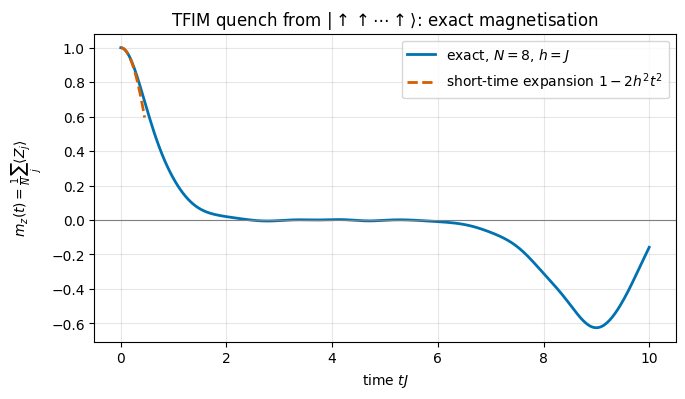

t = 0.0250:  m_z = 0.99875111,  1 - 2 h^2 t^2 = 0.99875000,  difference = 1.11e-06 = 2.83 * t^4
t = 0.0500:  m_z = 0.99501766,  1 - 2 h^2 t^2 = 0.99500000,  difference = 1.77e-05 = 2.83 * t^4


In [9]:
# ==============================================================================
# EXPERIMENT 1: magnetisation after the quench, exact (eigendecomposition)
# ==============================================================================
ts = jnp.linspace(0.0, T_FINAL, 401)
states_exact = evolve_eigh_many(E, V, psi0, ts)                 # (T, D)
probs = jnp.abs(states_exact) ** 2                              # (T, D)  Born probabilities of all basis states
mz_sites = probs @ ZTAB                                         # (T, N)  <Z_j>(t)
mz_exact = mz_sites.mean(axis=1)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(ts, mz_exact, color=C_BLUE, lw=2, label=r"exact, $N=8$, $h=J$")
t_short = np.linspace(0, 0.45, 50)
ax.plot(t_short, 1 - 2 * h ** 2 * t_short ** 2, "--", color=C_ORANGE, lw=2, label=r"short-time expansion $1-2h^2t^2$")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel(r"time $tJ$"); ax.set_ylabel(r"$m_z(t)=\frac{1}{N}\sum_j\langle Z_j\rangle$")
ax.set_title("TFIM quench from $|\\uparrow\\uparrow\\cdots\\uparrow\\rangle$: exact magnetisation")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# the remainder should behave as c4 * t^4: print it divided by t^4 at the first two grid times -- a constant confirms the order
for k_short in (1, 2):
    t_s = float(ts[k_short])
    err_short = abs(float(mz_exact[k_short]) - (1 - 2 * h ** 2 * t_s ** 2))
    print(f"t = {t_s:.4f}:  m_z = {float(mz_exact[k_short]):.8f},  1 - 2 h^2 t^2 = {1 - 2*h**2*t_s**2:.8f},  "
          f"difference = {err_short:.2e} = {err_short / t_s ** 4:.2f} * t^4")

**Interpretation.** The ferromagnetic order of the initial state melts: $m_z$ drops from 1 to about zero within $t\approx2/J$, following the parabola
$1-2h^2t^2$ at the very beginning: the printed remainder divided by $t^4$ is the same number ($\approx2.8$) at both times, which is what
"the next term is $O(t^4)$" means. (The expansion predicts the order of the remainder; the coefficient $2.8$ contains the $\tfrac23h^4$ of a
free spin plus a contribution from the coupling.) Afterwards it does not stay at zero: in a chain of only 8 spins
the excitations created by the quench travel to the ends, are reflected, and come back — and around $tJ\approx9$ they rebuild a magnetisation of magnitude $0.6$,
here with the *opposite* sign. These **finite-size revivals** are a property of the
small system; the method itself is exact. We come back to the physics in Section 8; first we need more methods.

## 5. Method 2 — the matrix exponential `expm`

### 5.1 Why summing the Taylor series fails

Equation (2) *defines* $e^{-iHt}$ as a power series, and the series converges for every matrix. So why not just sum it? Because of **catastrophic cancellation**.
The terms $\frac{(\|H\|t)^k}{k!}$ first *grow* — up to $k\approx\|H\|t$, where they reach about $e^{\|H\|t}$ — before the factorial wins. The result, however, is a unitary
matrix with entries of modulus $\le1$: huge terms of alternating phase must cancel to many digits. In floating-point arithmetic with relative
precision $\epsilon\approx10^{-16}$ each term carries an absolute round-off of about $\epsilon\times$(its size), so the sum is polluted by an error of order $\epsilon\,e^{\|H\|t}$.

Throughout this notebook $\|H\|$ means the **operator norm** (largest singular value); for a Hermitian matrix that is simply $\|H\|=\max_n|E_n|$,
the spectral radius. For our chain it is $9.838$, printed above — round it to 10:

| $t$ | $\Vert H\Vert t$ | largest term $\sim e^{\Vert H\Vert t}$ | expected error floor $\sim10^{-16}e^{\Vert H\Vert t}$ |
|---|---|---|---|
| 0.5 | 5 | $10^{2}$ | $10^{-14}$ |
| 2 | 20 | $10^{9}$ | $10^{-7}$ |
| 4 | 40 | $10^{17}$ | $10$ — all digits lost |

Let us see it. We sum the series for the *vector* $e^{-iHt}\psi_0$ (each new term is $-iHt/k$ times the previous one, so one matrix–vector product per term)
and record the error of every partial sum. The recurrence is a loop with a carry — exactly what `lax.scan` is for.

> **JAX practice.** `lax.scan(body, carry, xs)` runs `carry, y = body(carry, x)` for every `x` in `xs`, inside one compiled program, and stacks the `y`s.
> Here the carry is `(term, partial_sum)`. A Python `for` loop under `jit` would instead be *unrolled* into `K` copies of the body. See [notebook 01](../ch01_computational_toolbox/01_jax_from_scratch.ipynb).

t = 0.5: best achievable error of the Taylor sum = 6.8e-15, largest intermediate error = 1.1e+01
t = 2.0: best achievable error of the Taylor sum = 3.8e-09, largest intermediate error = 9.2e+06
t = 4.0: best achievable error of the Taylor sum = 1.1e+00, largest intermediate error = 2.0e+15


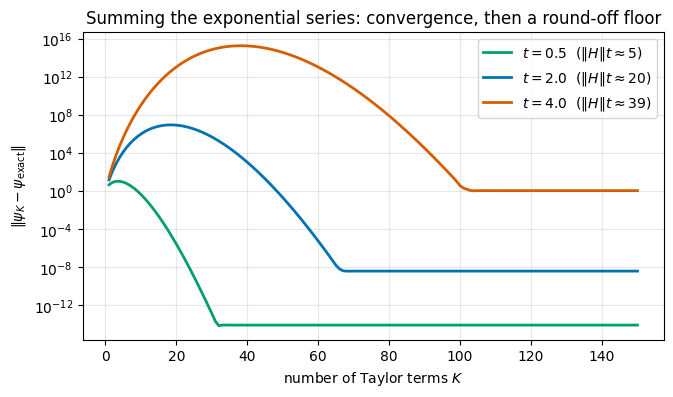

In [10]:
# ==============================================================================
# EXPERIMENT 2: partial sums of the Taylor series for exp(-iHt)|psi0>
# ==============================================================================
@jax.jit
def taylor_partial_sum_errors(H, psi0, t, psi_ref, ks):
    """Errors || sum_{k<=K} (-iHt)^k/k! psi0 - psi_ref ||  for K = 1, 2, ..., len(ks).

    MATH   term_k = (-i t H / k) term_{k-1},  term_0 = psi0   (one matvec per term)
    JAX    lax.scan with carry (term, partial sum); `ks` = [1., 2., ..., K] are the scanned inputs.
    """
    def body(carry, k):
        term, acc = carry
        term = (-1j * t / k) * (H @ term)
        acc = acc + term
        return (term, acc), jnp.linalg.norm(acc - psi_ref)

    _, errs = lax.scan(body, (psi0, psi0), ks)
    return errs


K_MAX = 150
ks = jnp.arange(1, K_MAX + 1, dtype=RDTYPE)
fig, ax = plt.subplots(figsize=(7.5, 4))
for t_taylor, col in zip((0.5, 2.0, 4.0), (C_GREEN, C_BLUE, C_ORANGE)):
    errs = taylor_partial_sum_errors(H, psi0, t_taylor, evolve_eigh(E, V, psi0, t_taylor), ks)
    ax.semilogy(ks, errs, color=col, lw=2, label=rf"$t={t_taylor}$  ($\|H\|t\approx{float(jnp.max(jnp.abs(E)))*t_taylor:.0f}$)")
    print(f"t = {t_taylor}: best achievable error of the Taylor sum = {float(jnp.min(errs)):.1e}, largest intermediate error = {float(jnp.max(errs)):.1e}")
ax.set_xlabel("number of Taylor terms $K$"); ax.set_ylabel(r"$\|\psi_K-\psi_{\rm exact}\|$")
ax.set_title("Summing the exponential series: convergence, then a round-off floor")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()

**Interpretation.** For $\|H\|t\approx5$ the series converges to machine precision with about 30 terms. For $\|H\|t\approx20$ the partial sums first
*explode* (errors of order $10^{7}$) before converging, and the final accuracy is stuck several orders of magnitude above machine precision. For $\|H\|t\approx40$
the partial sums reach $\sim10^{15}$ and the "converged" result is garbage: its error is of order one or larger, i.e. not a single correct digit, however many terms are summed.
The floors follow the estimate $\epsilon\,e^{\|H\|t}$ of the table (within one or two orders of magnitude — the vector $\psi_0$ does not probe the worst case).

### 5.2 What `expm` does instead: scaling and squaring

The cure uses the group property: $e^{A}=\big(e^{A/2^s}\big)^{2^s}$. Choose $s$ such that $\|A\|/2^s\lesssim1$; for such a small argument a short expansion is both accurate and free of
cancellation (libraries use a *Padé approximant*, a ratio of two polynomials, which is more economical than the Taylor polynomial); then square the result $s$ times.
Cost: a handful of $D\times D$ matrix products plus $s\approx\log_2\|A\|$ squarings — $O(D^3)$, the same order as `eigh`. This is what `jax.scipy.linalg.expm`
(like SciPy and MATLAB) implements; we quote the algorithm without proof, see Moler & Van Loan and Higham in the references.

`expm` needs no Hermiticity, so it also works for non-Hermitian generators (open systems, imaginary time). For Hermitian $H$ the eigendecomposition is usually preferable:
one factorisation serves *all* times, while `expm` must be called again for each new $t$.

In [11]:
# ==============================================================================
# CHECKPOINT 4: expm versus eigendecomposition  (+ timing: compile time vs run time)
# ==============================================================================
t_test = 4.0                                                       # the time at which the Taylor series failed
t0 = time.perf_counter()
U_expm = expm(-1j * H * t_test).block_until_ready()                # first call: includes compilation
t_first = time.perf_counter() - t0
t0 = time.perf_counter()
U_expm = expm(-1j * H * t_test).block_until_ready()                # second call: run time only
t_second = time.perf_counter() - t0

err_expm = max_abs(U_expm - propagator_eigh(E, V, t_test))
err_expm_unitary = max_abs(U_expm.conj().T @ U_expm - jnp.eye(2 ** N))
print(f"expm, first call (compile + run): {t_first:.3f} s | second call (run only): {t_second:.3f} s")
print(f"||expm(-iHt) - V e^(-iEt) V^dag||_max = {err_expm:.1e}     unitarity of expm result: {err_expm_unitary:.1e}")
assert err_expm < 100 * TOL and err_expm_unitary < 100 * TOL

expm, first call (compile + run): 0.548 s | second call (run only): 0.036 s
||expm(-iHt) - V e^(-iEt) V^dag||_max = 4.4e-15     unitarity of expm result: 1.6e-15


Two completely different algorithms agree to round-off at the same $t=4$ where the naive series lost all digits. The first call is several times slower than the second, and the reason is not the mathematics:

> **JAX practice.** JAX compiles a function the first time it meets a new combination of input shapes and dtypes; later calls reuse the compiled program. JAX also
> dispatches work *asynchronously* — Python gets the handle of a result before the computation has finished. Our timing code therefore (i) calls `.block_until_ready()`
> before stopping the clock and (ii) reports the first call separately from subsequent ones.

## 6. Method 3 — the Schrödinger equation as an ODE

Both methods so far need $O(D^3)$ operations on a dense matrix. A tempting alternative: treat $\dot\psi=f(\psi)$ with $f(\psi)=-iH\psi$ as an ordinary differential
equation and integrate it step by step, as one would integrate Newton's equations. Each step needs only matrix–vector products $H\psi$, $O(D^2)$.

### 6.1 Explicit Euler, and why it must fail

The simplest integrator replaces the derivative by a finite difference, $\psi(t+dt)\approx\psi(t)+dt\,\dot\psi(t)$:

$$ \psi_{n+1}=(\mathbb 1-iH\,dt)\,\psi_n . \tag{5}$$

This is the exponential series truncated after the linear term, so the error made in one step (**local error**) is $O(dt^2)$; after $n=t/dt$ steps the **global error** is $O(dt)$:
a *first-order* method. But there is a more serious problem: the matrix $\mathbb 1-iH\,dt$ is **not unitary**. Apply it to an eigenstate $|n\rangle$:

$$ (\mathbb 1-iH\,dt)|n\rangle=(1-iE_ndt)|n\rangle,\qquad |1-iE_ndt|=\sqrt{1+E_n^2dt^2}>1 . $$

The exact evolution multiplies the amplitude by the pure phase $e^{-iE_ndt}$ (modulus 1); Euler multiplies it by a number of modulus **larger than one**, in every step. Since the eigenstates are
orthogonal, the norm after $n$ steps is, *exactly*,

$$ \|\psi_n\|^2=\sum_m|c_m|^2\,(1+E_m^2dt^2)^{n},\qquad c_m=\langle m|\psi_0\rangle . \tag{6}$$

For small $dt$: $(1+E^2dt^2)^{t/dt}\approx e^{E^2\,t\,dt}$ — exponential growth in time for any fixed $dt$. Reducing $dt$ only postpones the explosion. Let us verify the prediction (6) to the last digit.

### 6.2 From formula to code

A one-step method is a function `step(H, psi, dt) -> psi_new`. The time loop is a `lax.scan` whose carry is the state and whose stacked output is the whole trajectory, shape `(n_steps+1, D)`.
The step itself is written as whole-array operations, as in Chapter B16 of *Numerical Recipes in Fortran 90*.
The step function and the number of steps are *static* arguments of `jit` (they determine the structure of the compiled program), `H`, `psi0` and `dt` are traced arrays.

In [12]:
# ==============================================================================
# STEP 4: one-step ODE integrators and a generic scan-based time loop
# ==============================================================================
def euler_step(H, psi, dt):
    """Explicit Euler step for  d psi/dt = -i H psi:   psi_{n+1} = (1 - i H dt) psi_n.    Local error O(dt^2); NOT unitary."""
    return psi - 1j * dt * (H @ psi)


def rk4_step(H, psi, dt):
    """Classical 4th-order Runge-Kutta step for  d psi/dt = f(psi) = -i H psi.

    MATH   k1 = f(psi), k2 = f(psi + dt/2 k1), k3 = f(psi + dt/2 k2), k4 = f(psi + dt k3),
           psi_{n+1} = psi + dt/6 (k1 + 2 k2 + 2 k3 + k4).
           For a LINEAR equation this equals the Taylor polynomial of exp(-iH dt) up to (dt)^4:  local error O(dt^5).
    COST   4 matrix-vector products per step.  Not unitary (see Section 6.3).
    """
    f = lambda p: -1j * (H @ p)
    k1 = f(psi)
    k2 = f(psi + 0.5 * dt * k1)
    k3 = f(psi + 0.5 * dt * k2)
    k4 = f(psi + dt * k3)
    return psi + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


@partial(jax.jit, static_argnames=("step_fn", "n_steps", "record"))
def integrate(step_fn, H, psi0, dt, n_steps, record=True):
    """Apply `step_fn` n_steps times.  Returns the trajectory, shape (n_steps+1, D), including the initial state
    (record=True), or only the final state, shape (D,) (record=False: saves memory in convergence studies).

    JAX    lax.scan: the step is compiled ONCE and iterated inside XLA.  `step_fn`, `n_steps` and `record` are static
           (they fix the structure/length of the loop); H, psi0, dt are traced, so changing dt does not recompile.
    """
    def body(psi, _):
        psi_new = step_fn(H, psi, dt)
        return psi_new, (psi_new if record else None)

    psi_final, traj = lax.scan(body, psi0, None, length=n_steps)
    return jnp.concatenate([psi0[None, :], traj], axis=0) if record else psi_final

dt = 0.02  : norm at t=10 is  5.499e+03   | max relative deviation from Eq. (6): 1.7e-14


dt = 0.01  : norm at t=10 is  5.993e+01   | max relative deviation from Eq. (6): 4.8e-15


dt = 0.005 : norm at t=10 is  6.503e+00   | max relative deviation from Eq. (6): 3.0e-14


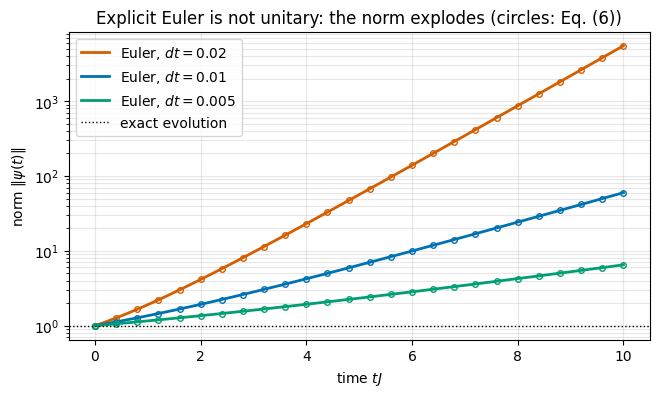

In [13]:
# ==============================================================================
# EXPERIMENT 3: Euler's norm blow-up, measured and predicted by Eq. (6)
# ==============================================================================
c2 = jnp.abs(V.conj().T @ psi0) ** 2                                  # |c_m|^2: weights of psi0 on the energy eigenstates

fig, ax = plt.subplots(figsize=(7.5, 4))
for dt_e, col in zip((0.02, 0.01, 0.005), (C_ORANGE, C_BLUE, C_GREEN)):
    n_e = int(round(T_FINAL / dt_e))
    traj = integrate(euler_step, H, psi0, dt_e, n_e)
    norms = jnp.linalg.norm(traj, axis=1)
    steps = jnp.arange(n_e + 1)
    norms_pred = jnp.sqrt(jnp.sum(c2[None, :] * (1 + (E[None, :] * dt_e) ** 2) ** steps[:, None], axis=1))   # Eq. (6)
    rel = float(jnp.max(jnp.abs(norms / norms_pred - 1)))
    ax.semilogy(steps * dt_e, norms, color=col, lw=2, label=rf"Euler, $dt={dt_e}$")
    ax.semilogy(steps[::n_e // 25] * dt_e, norms_pred[::n_e // 25], "o", color=col, ms=4, mfc="none")
    print(f"dt = {dt_e:<6}: norm at t={T_FINAL:g} is {float(norms[-1]):10.3e}   | max relative deviation from Eq. (6): {rel:.1e}")
    assert rel < 1e4 * TOL
ax.axhline(1.0, color="k", lw=1, ls=":", label="exact evolution")
ax.set_xlabel(r"time $tJ$"); ax.set_ylabel(r"norm $\|\psi(t)\|$")
ax.set_title("Explicit Euler is not unitary: the norm explodes (circles: Eq. (6))")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()

**Interpretation.** With $dt=0.02$ the "probability" has grown by orders of magnitude at $t=10$; halving the step halves the *exponent* — it never removes the growth. The circles are the
prediction (6): they agree with the measured norms to round-off, so we understand this failure completely. One could renormalise the state after each step,
but that cures the symptom only: the relative weights of the energy eigenstates are still distorted (high-$|E|$ components are amplified most), and energy is not conserved.

> **Common pitfall.** "My wave function blows up" is most often a non-unitary integrator with too large a step. Always monitor $\|\psi\|$ and $\langle H\rangle$.

### 6.3 Runge–Kutta 4: much better, still not unitary

The classical fourth-order Runge–Kutta method (RK4; Press *et al.*, *Numerical Recipes*, §17.1) evaluates $f$ four times per step and combines the results so that the Taylor expansion of the exact solution is reproduced up
to $dt^4$. For our *linear* equation one can substitute the stages into each other and finds that a step is multiplication with the degree-4 Taylor polynomial,

$$ \psi_{n+1}=R(-iH\,dt)\,\psi_n,\qquad R(z)=1+z+\frac{z^2}{2}+\frac{z^3}{6}+\frac{z^4}{24}. $$

The local error is $O(dt^5)$, the global error $O(dt^4)$. On an eigenstate, with $y=E_ndt$, the amplification factor is $R(-iy)$ with

$$ |R(-iy)|^2=\Big(1-\frac{y^2}{2}+\frac{y^4}{24}\Big)^2+\Big(y-\frac{y^3}{6}\Big)^2=1-\frac{y^6}{72}+\frac{y^8}{576}. \tag{7}$$

(Multiply out and collect powers: the $y^2$ and $y^4$ terms cancel.) Two consequences:

* for small $y$ the norm **decays** slowly, by a factor $1-y^6/144$ per step — a weak, artificial damping of the high-energy components;
* $|R|\le1$ only if $y^2\le8$: the method is **stable only for** $dt\,\max_n|E_n|\le2\sqrt2\approx2.83$. Beyond that threshold it explodes like Euler. The spectral radius of a many-body $H$ grows
  linearly with $N$, so the admissible step shrinks as the system grows.

We measure three things: the norm drift at a reasonable step, the instability beyond the threshold, and the order of convergence of both ODE methods.

max|E_n| = 9.838  ->  RK4 stability threshold dt_crit = 2 sqrt(2)/max|E| = 0.2875


RK4 dt = 0.05 : norm at t=30 is 9.787292e-01


RK4 dt = 0.2  : norm at t=30 is 4.121647e-01


RK4 dt = 0.27 : norm at t=30 is 3.317561e-01


RK4 dt = 0.3  : norm at t=30 is 3.035206e+12


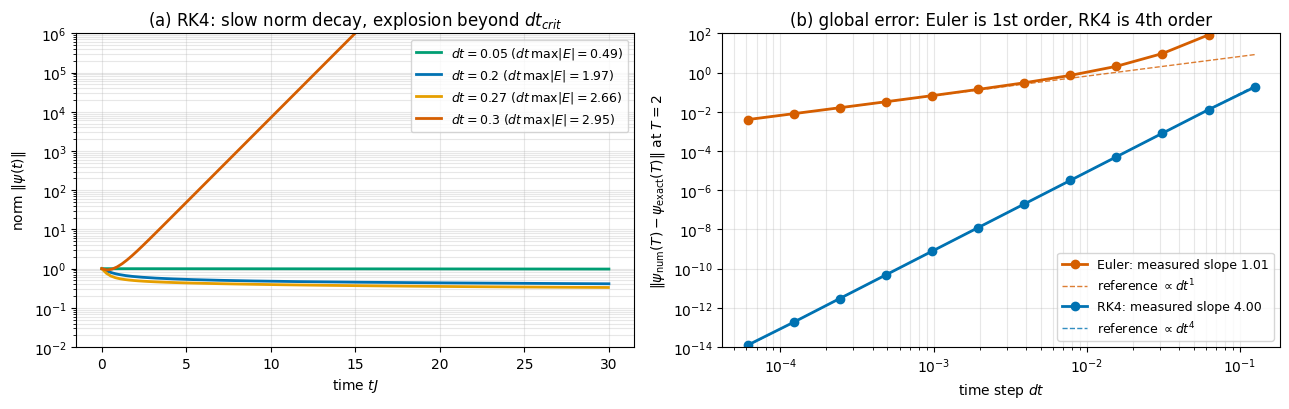

measured orders: Euler 1.01 (expected 1),  RK4 4.00 (expected 4)


In [14]:
# ==============================================================================
# EXPERIMENT 4: RK4 -- norm drift, stability threshold, and measured orders of Euler and RK4
# ==============================================================================
E_abs_max = float(jnp.max(jnp.abs(E)))
dt_crit = 2 * np.sqrt(2) / E_abs_max
print(f"max|E_n| = {E_abs_max:.3f}  ->  RK4 stability threshold dt_crit = 2 sqrt(2)/max|E| = {dt_crit:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# (a) norm versus time for a few step sizes, below and above the threshold
ax = axes[0]
for dt_r, col in zip((0.05, 0.2, 0.27, 0.30), (C_GREEN, C_BLUE, C_YELLOW, C_ORANGE)):
    n_r = int(round(30.0 / dt_r))
    norms = jnp.linalg.norm(integrate(rk4_step, H, psi0, dt_r, n_r), axis=1)
    ax.semilogy(jnp.arange(n_r + 1) * dt_r, norms, color=col, lw=2,
                label=rf"$dt={dt_r}$ ($dt\,\max|E|={dt_r*E_abs_max:.2f}$)")
    print(f"RK4 dt = {dt_r:<5}: norm at t=30 is {float(norms[-1]):.6e}")
ax.set_ylim(1e-2, 1e6)
ax.set_xlabel(r"time $tJ$"); ax.set_ylabel(r"norm $\|\psi(t)\|$"); ax.set_title("(a) RK4: slow norm decay, explosion beyond $dt_{crit}$")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")

# (b) global error at fixed final time versus dt  -> measured order of accuracy
ax = axes[1]
T_CONV = 2.0
psi_ref = evolve_eigh(E, V, psi0, T_CONV)
n_list = np.array([2 ** k for k in range(4, 16)])                   # 16 ... 32768 steps
dts_conv = T_CONV / n_list
slopes_ode = {}
for name, step_fn, col, p in (("Euler", euler_step, C_ORANGE, 1), ("RK4", rk4_step, C_BLUE, 4)):
    errs = np.array([float(jnp.linalg.norm(integrate(step_fn, H, psi0, T_CONV / n, int(n), record=False) - psi_ref)) for n in n_list])
    good = (errs > TOL) & (errs < 0.1)                              # fit only the asymptotic regime, above the round-off floor
    slopes_ode[name] = np.polyfit(np.log(dts_conv[good]), np.log(errs[good]), 1)[0]
    ax.loglog(dts_conv, errs, "o-", color=col, lw=2, label=f"{name}: measured slope {slopes_ode[name]:.2f}")
    i_ref = np.where(good)[0][len(np.where(good)[0]) // 2]
    ax.loglog(dts_conv, errs[i_ref] * (dts_conv / dts_conv[i_ref]) ** p, "--", color=col, lw=1, alpha=0.8, label=rf"reference $\propto dt^{p}$")
ax.set_ylim(1e-14, 1e2)
ax.set_xlabel(r"time step $dt$"); ax.set_ylabel(rf"$\|\psi_{{\rm num}}(T)-\psi_{{\rm exact}}(T)\|$ at $T={T_CONV:g}$")
ax.set_title("(b) global error: Euler is 1st order, RK4 is 4th order")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print(f"measured orders: Euler {slopes_ode['Euler']:.2f} (expected 1),  RK4 {slopes_ode['RK4']:.2f} (expected 4)")
assert abs(slopes_ode["Euler"] - 1) < 0.25 and abs(slopes_ode["RK4"] - 4) < 0.25

**Interpretation.**

* *(a)* Below the threshold RK4 does not blow up, but it is not norm-conserving either: each step multiplies the amplitude of the eigenstate $|n\rangle$ by
  $|R(-iE_ndt)|\approx1-(E_ndt)^6/144$, and that sixth power makes all the difference. For $dt=0.05$ ($\max|E|dt\approx0.5$) the loss is a couple of per cent after $t=30$,
  invisible on this scale; for $dt=0.2$ ($\max|E|dt\approx2$) more than half of the norm is gone by $t=30$ — compare the printed numbers.
  Just beyond $dt_{crit}$ the norm explodes. Close to the threshold (yellow curve) the method is formally stable but strongly damps the components at the spectral edges — the result is wrong even though nothing blows up.
* *(b)* **This is how the order of a method is measured**: fix the final time, halve $dt$ repeatedly, plot the error on log–log axes and read off the slope. Euler: slope 1. RK4: slope 4, down to
  the round-off floor near $10^{-13}$. To gain one digit of accuracy Euler needs 10 times more steps, RK4 only $10^{1/4}\approx1.8$ times more.

> **Numerical practice.** A log–log error plot with reference slopes is the single most useful diagnostic of a time integrator. If the measured slope is not the theoretical one,
> there is a bug (or you are outside the asymptotic regime: $dt$ too large, or already at the round-off floor).

### 6.4 The step-size rule for RK4, and what it costs as the chain grows

The stability condition $y^2\le8$ of Eq. (7) holds for *every* eigenvalue simultaneously, $y=E_n\,dt$. The binding one is the largest $|E_n|$, i.e. the
operator norm $\|H\|$. This is the rule to carry around:

$$ \boxed{\;dt\,\|H\|\;\le\;2\sqrt2\approx2.83\qquad\text{i.e.}\qquad dt\;\le\;\frac{2\sqrt2}{\max_n|E_n|}\;} \tag{7a}$$

It is *necessary*, not sufficient: the $dt=0.27$ curve of panel (a) satisfies it and is still useless, because components near the spectral edges are damped away.
A working rule of thumb is $dt\,\|H\|\lesssim1$, well inside the stability region.

**What $\|H\|$ is for a spin chain.** $H$ is a sum of $2N-1$ terms (Eq. (1)), each of which is a coupling or a field times a product of Pauli matrices, and each
Pauli product has norm 1. The triangle inequality therefore gives, for the TFIM,

$$ \|H\|\;\le\;\sum_{\rm terms}\|{\rm term}\|\;=\;J\,(N-1)+h\,N , $$

and the true norm is a fixed fraction of that bound. $\|H\|$ is **extensive**: it grows *linearly with the number of spins*, because energy is extensive.
The next cell measures it.

At a fixed final time $T$ the number of RK4 steps is

$$ n=\frac{T}{dt}\;\ge\;\frac{T\,\|H\|}{2\sqrt2}\;\propto\;N , $$

so RK4 pays an extra factor $N$ *on top of* the $O(4^N)$ cost of the matrix–vector products in each step: doubling the chain roughly doubles the number of
steps needed to reach the same physical time, whatever accuracy you are content with. And unlike a discretisation parameter, $\|H\|$ cannot be reduced by
being more careful — it is a property of the physical system.

> **Numerical practice.** Every explicit integrator has such a rule, with the same $2\sqrt2$ but a different $\|H\|$. In
> [notebook 00b](../ch01_computational_toolbox/00b_first_quantum_simulation_harmonic_oscillator.ipynb) the same Eq. (7a) was applied to a particle on a
> grid, where the largest eigenvalue of the discretised kinetic operator is $E_{\max}\simeq2/\Delta x^2$, and it turned into $\Delta t\lesssim\sqrt2\,\Delta x^2$:
> halving the grid spacing forces four times as many time steps. Here the same rule reads $dt\lesssim2\sqrt2/\|H\|$ with $\|H\|\propto N$. Compute $\|H\|$
> (or a bound on it) *before* choosing $dt$ — never after seeing the norm blow up.

In [15]:
# ==============================================================================
# STEP 5: the spectral norm of the TFIM chain grows linearly with N  ->  Eq. (7a) tightens as N grows
# ==============================================================================
print(f"{'N':>3} {'max|E_n| = ||H||':>18} {'J(N-1)+hN (bound)':>19} {'||H||/N':>9} {'dt_crit = 2 sqrt(2)/||H||':>26}")
for n_norm in (4, 6, 8, 10, 12):
    Hn = build_hamiltonian_dense(n_norm, 0.0, 0.0, -J, -h, 0.0, 0.0)
    nrm = float(jnp.max(jnp.abs(jnp.linalg.eigvalsh(Hn))))
    print(f"{n_norm:>3} {nrm:>18.4f} {J*(n_norm-1)+h*n_norm:>19.1f} {nrm/n_norm:>9.4f} {2*np.sqrt(2)/nrm:>26.4f}")
    del Hn

  N   max|E_n| = ||H||   J(N-1)+hN (bound)   ||H||/N  dt_crit = 2 sqrt(2)/||H||


  4             4.7588                 7.0    1.1897                     0.5944


  6             7.2962                11.0    1.2160                     0.3877
  8             9.8380                15.0    1.2297                     0.2875


 10            12.3815                19.0    1.2381                     0.2284


 12            14.9260                23.0    1.2438                     0.1895


The norm grows linearly: the ratio $\|H\|/N$ printed in the third column climbs from $1.19$ at $N=4$ towards about $1.25$, always safely below the bound $J(N-1)+hN=2N-1$.
The admissible RK4 step shrinks in proportion — it is already below $0.19$ at $N=12$, and it would be about $0.02$ for a chain of a hundred spins.

### 6.5 Why unitary methods are preferred

RK4 is a perfectly respectable general-purpose choice and we will meet it again for open quantum systems, where the evolution is not unitary anyway. For closed quantum systems it has three drawbacks:

1. **No structure preservation.** Norm and energy drift systematically; the errors accumulate over long times instead of averaging out.
2. **Conditional stability.** Eq. (7a): $dt\le2\sqrt2/\|H\|$ with $\|H\|\propto N$.
3. **It treats $H$ as a whole.** Every stage needs $H\psi$ for the full $H$; the method makes no use of the fact that $H$ is a sum of local terms whose exponentials are cheap.

The exact propagator is unitary; it is natural to demand the same from its approximation. The method of the next section is exactly unitary for every $dt$ (hence unconditionally stable), is built from
exponentials of *small* matrices only, and is the basis of the most important algorithms for quantum many-body dynamics — on classical and on quantum computers alike.

## 7. Trotterization of the propagator

### 7.1 The problem: $e^{A+B}\neq e^Ae^B$

Our Hamiltonian is a sum of simple pieces. Take the TFIM, $H=H_{zz}+H_x$:

* $H_{zz}=-J\sum_jZ_jZ_{j+1}$ is *diagonal* in the computational basis; its exponential is a diagonal matrix of phases — trivial;
* $H_x=-h\sum_jX_j$ is a sum of commuting single-spin terms; its exponential is a Kronecker product of $2\times2$ rotations $e^{ihtX}=\cos(ht)\mathbb 1+i\sin(ht)X$ — also trivial.

If numbers were matrices we would write $e^{-i(H_{zz}+H_x)t}=e^{-iH_{zz}t}e^{-iH_xt}$ and be done. For matrices this is **false** in general. Where exactly does the proof for numbers break? Multiply the two series:

$$ e^Ae^B=\sum_{k,l}\frac{A^kB^l}{k!\,l!}\quad\text{(all $A$'s to the left of all $B$'s)},\qquad e^{A+B}=\sum_m\frac{(A+B)^m}{m!}. $$

Already at second order $(A+B)^2=A^2+AB+BA+B^2$ contains both orderings, while $e^Ae^B$ contains only $AB$. The two agree if and only if we may reorder, $AB=BA$. In that case the binomial theorem
$(A+B)^m=\sum_k\binom mkA^kB^{m-k}$ holds as for numbers, and the double series re-sums to $e^{A+B}$:

$$ [A,B]=0\quad\Longrightarrow\quad e^{A+B}=e^Ae^B . \tag{8}$$

(We used this already: $Ht_1$ and $Ht_2$ commute, which gave the group property of $U(t)$.) The obstruction is the **commutator** $[A,B]=AB-BA$. Since $[Z_jZ_{j+1},X_j]\neq0$, the two pieces of the TFIM do not commute.

**The smallest example: one spin in a tilted field.** $H=aX+bZ$. Exactly as in Section 4.3, $(aX+bZ)^2=(a^2+b^2)\mathbb 1\equiv\omega^2\mathbb 1$ (the cross terms cancel because $XZ=-ZX$), so
$e^{-iHt}=\cos(\omega t)\mathbb 1-i\sin(\omega t)\,(aX+bZ)/\omega$: a rotation of the spin about the *tilted* axis $(a,0,b)$. The product $e^{-ibZt}e^{-iaXt}$ is instead a rotation about $x$ followed by a rotation about $z$.
Rotations about different axes do not commute, and this is the entire origin of the discrepancy.

In [16]:
# ==============================================================================
# EXPERIMENT 5: exponentials of non-commuting matrices, one spin:  H = a X + b Z
# ==============================================================================
a, b, t1 = 0.6, 0.8, 1.0                                     # omega = sqrt(a^2 + b^2) = 1
omega = np.sqrt(a ** 2 + b ** 2)
U_closed = jnp.cos(omega * t1) * I2 - 1j * jnp.sin(omega * t1) * (a * X + b * Z) / omega     # derived above
U_joint = expm(-1j * (a * X + b * Z) * t1)
U_split = expm(-1j * b * Z * t1) @ expm(-1j * a * X * t1)

print(f"closed form vs expm            : {max_abs(U_closed - U_joint):.1e}")
print(f"|| e^(-iHt) - e^(-ibZt) e^(-iaXt) ||_max = {max_abs(U_joint - U_split):.3f}     <- NOT small: the exponentials do not factorise")
print(f"commuting case, A = aX, B = bX : {max_abs(expm(-1j*(a+b)*X*t1) - expm(-1j*a*X*t1) @ expm(-1j*b*X*t1)):.1e}  <- Eq. (8)")
assert max_abs(U_closed - U_joint) < 100 * TOL

closed form vs expm            : 1.1e-16
|| e^(-iHt) - e^(-ibZt) e^(-iaXt) ||_max = 0.420     <- NOT small: the exponentials do not factorise
commuting case, A = aX, B = bX : 2.5e-16  <- Eq. (8)


For $t=1$ the factorised form is off by an amount of order one. But look at what happens for *short* times.

### 7.2 The Baker–Campbell–Hausdorff formula to the order we need

Let $\varepsilon$ be a small number (later: $\varepsilon=dt$, and $A,B$ stand for $-iH_A,-iH_B$). Expand both sides to second order:

$$ e^{\varepsilon A}e^{\varepsilon B}=\Big(1+\varepsilon A+\frac{\varepsilon^2}{2}A^2\Big)\Big(1+\varepsilon B+\frac{\varepsilon^2}{2}B^2\Big)+O(\varepsilon^3)
   =1+\varepsilon(A+B)+\frac{\varepsilon^2}{2}\big(A^2+2AB+B^2\big)+O(\varepsilon^3), $$

$$ e^{\varepsilon(A+B)}=1+\varepsilon(A+B)+\frac{\varepsilon^2}{2}\big(A^2+AB+BA+B^2\big)+O(\varepsilon^3). $$

Subtracting,

$$ e^{\varepsilon A}e^{\varepsilon B}-e^{\varepsilon(A+B)}=\frac{\varepsilon^2}{2}[A,B]+O(\varepsilon^3). \tag{9}$$

**The error of factorising a short-time propagator is second order in the time step, and its prefactor is the commutator.** One can go further and ask: the product $e^{\varepsilon A}e^{\varepsilon B}$ is *some* exponential
$e^{\Omega(\varepsilon)}$ — of what? Write $\Omega=\varepsilon\Omega_1+\varepsilon^2\Omega_2+\dots$, expand $e^{\Omega}=1+\varepsilon\Omega_1+\varepsilon^2(\Omega_2+\tfrac12\Omega_1^2)+\dots$ and compare with the first line above:
$\Omega_1=A+B$ and $\Omega_2=\tfrac12(A^2+2AB+B^2)-\tfrac12(A+B)^2=\tfrac12[A,B]$. Continuing to the next order (tedious; we quote the result) gives the **Baker–Campbell–Hausdorff (BCH) formula**

$$ e^{\varepsilon A}e^{\varepsilon B}=\exp\Big(\varepsilon(A+B)+\frac{\varepsilon^2}{2}[A,B]+\frac{\varepsilon^3}{12}\big([A,[A,B]]+[B,[B,A]]\big)+O(\varepsilon^4)\Big). \tag{10}$$

All higher terms are nested commutators too: if $[A,B]=0$ they all vanish and we recover Eq. (8).

Before building on Eqs. (9) and (10) we **verify them numerically**, for random anti-Hermitian $4\times4$ matrices $A,B$ (so that the exponentials are unitary, as in our application).
The logic of the test: if a formula is correct up to terms of order $\varepsilon^{p}$, then the residual must shrink by $2^{p}$ each time we halve $\varepsilon$; the *observed order* $\log_2(r(\varepsilon)/r(\varepsilon/2))$ must equal $p$.

In [17]:
# ==============================================================================
# CHECKPOINT 5: numerical verification of the BCH formula, Eqs. (9) and (10)
# ==============================================================================
def random_antihermitian(key, d):
    """Random d x d matrix A with A^dag = -A  (so that exp(A) is unitary).  A = (G - G^dag)/2 with Gaussian G."""
    k1, k2 = jax.random.split(key)
    G = jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))
    return ((G - G.conj().T) / 2).astype(CDTYPE)


def comm(A, B):
    """Commutator [A, B] = AB - BA."""
    return A @ B - B @ A


kA, kB = jax.random.split(jax.random.PRNGKey(42))
A_r, B_r = random_antihermitian(kA, 4), random_antihermitian(kB, 4)
fro = lambda M: float(jnp.linalg.norm(M))                       # Frobenius norm

eps_list = [0.2, 0.1, 0.05, 0.025]
res = {"naive": [], "eq9": [], "bch2": [], "bch3": []}
for eps in eps_list:
    P = expm(eps * A_r) @ expm(eps * B_r)
    res["naive"].append(fro(P - expm(eps * (A_r + B_r))))
    res["eq9"].append(fro(P - expm(eps * (A_r + B_r)) - 0.5 * eps ** 2 * comm(A_r, B_r)))
    res["bch2"].append(fro(P - expm(eps * (A_r + B_r) + 0.5 * eps ** 2 * comm(A_r, B_r))))
    res["bch3"].append(fro(P - expm(eps * (A_r + B_r) + 0.5 * eps ** 2 * comm(A_r, B_r)
                                    + eps ** 3 / 12 * (comm(A_r, comm(A_r, B_r)) + comm(B_r, comm(B_r, A_r))))))

labels = {"naive": "e^A e^B - e^(A+B)                     ", "eq9": "... - eps^2/2 [A,B]          (Eq. 9) ",
          "bch2": "e^A e^B - exp(BCH up to eps^2)        ", "bch3": "e^A e^B - exp(BCH up to eps^3) (Eq.10)"}
expected = {"naive": 2, "eq9": 3, "bch2": 3, "bch3": 4}
print("residual".ljust(40) + "".join(f"eps={e:<9}" for e in eps_list) + " observed order (last halving) / expected")
for name in res:
    r = res[name]
    order = np.log2(r[-2] / r[-1])
    print(labels[name] + "  " + "".join(f"{x:<13.2e}" for x in r) + f" {order:.2f} / {expected[name]}")
    if PRECISION == "double":
        assert abs(order - expected[name]) < 0.35

residual                                eps=0.2      eps=0.1      eps=0.05     eps=0.025     observed order (last halving) / expected
e^A e^B - e^(A+B)                       2.58e-01     6.71e-02     1.69e-02     4.24e-03      2.00 / 2
... - eps^2/2 [A,B]          (Eq. 9)   9.43e-02     1.19e-02     1.49e-03     1.87e-04      3.00 / 3
e^A e^B - exp(BCH up to eps^2)          5.73e-02     7.14e-03     8.91e-04     1.11e-04      3.00 / 3
e^A e^B - exp(BCH up to eps^3) (Eq.10)  8.02e-03     4.85e-04     3.00e-05     1.87e-06      4.00 / 4


Each correction raises the observed order by exactly one: the naive factorisation leaves a residual $\propto\varepsilon^2$; subtracting $\frac{\varepsilon^2}2[A,B]$ leaves $\varepsilon^3$; including the quoted
third-order BCH term leaves $\varepsilon^4$. The formulas — including the one we did not derive — are confirmed.

> **Numerical practice.** You can *test a formula you cannot derive*: a wrong coefficient in Eq. (10) would leave the observed order at 3.

### 7.3 The Lie–Trotter product formula: many short steps

A short-time factorisation with error $O(dt^2)$ is all we need, thanks to the group property $U(t)=U(dt)^n$, $n=t/dt$:

$$ e^{-i(H_A+H_B)t}=\Big(e^{-iH_B\,dt}\,e^{-iH_A\,dt}\Big)^{n}+O(t\,dt) \qquad\textbf{(first-order Trotter, } U_1(dt)=e^{-iH_Bdt}e^{-iH_Adt}). \tag{11}$$

Why does a *local* error $O(dt^2)$ become a *global* error $O(t\,dt)$? Let $U$ be the exact step and $\tilde U$ the approximate one, both unitary. The telescoping identity

$$ \tilde U^n-U^n=\sum_{k=0}^{n-1}\tilde U^{\,n-1-k}\,(\tilde U-U)\,U^{k} $$

holds for any two matrices. (Write out $n=2$: $\tilde U(\tilde U-U)+(\tilde U-U)U=\tilde U^2-\tilde UU+\tilde UU-U^2=\tilde U^2-U^2$. The middle terms cancel
pairwise, and the same happens for every $n$ — each summand contributes $\tilde U^{n-k}U^k-\tilde U^{n-1-k}U^{k+1}$, a telescoping sum from $\tilde U^n$ to $U^n$.)
Taking norms, using $\|AB\|\le\|A\|\,\|B\|$ and $\|\tilde U\|=\|U\|=1$ for unitary matrices (operator norm), gives

$$ \|\tilde U^n-U^n\|\le n\,\|\tilde U-U\| . \tag{12}$$

**Errors of unitary steps add up at most linearly — they are never amplified.** (Compare with Euler, where the step matrix has norm $>1$ and errors are amplified exponentially.) With
$\|\tilde U-U\|\approx\frac{dt^2}{2}\|[H_A,H_B]\|$ from Eq. (9) and $n=t/dt$:

$$ \big\|U_1(dt)^{n}-e^{-iHt}\big\|\;\lesssim\;\frac{t\,dt}{2}\,\big\|[H_A,H_B]\big\| . \tag{13}$$

In the limit $n\to\infty$ the product formula becomes exact; this is the *Lie product formula* (for matrices) or *Trotter formula* (for operators; Trotter 1959).

Two features deserve emphasis. First, every factor is the exponential of a Hermitian matrix times $-i$, hence **exactly unitary, for any $dt$**: norm conservation is built in, the method cannot blow up.
Second, by BCH the Trotter step is the *exact* propagator of a slightly wrong, but Hermitian, Hamiltonian: inserting $\varepsilon A\to-iH_Bdt$ and $\varepsilon B\to-iH_Adt$ into Eq. (10) and factoring out $-i\,dt$,

$$ U_1(dt)=e^{-iH_{\rm eff}dt},\qquad H_{\rm eff}=H-\frac{i\,dt}{2}[H_B,H_A]+O(dt^2) $$

($[H_B,H_A]$ is anti-Hermitian, since $[A,B]^\dagger=-[A,B]$ for Hermitian $A,B$, so $i[H_B,H_A]$ and hence $H_{\rm eff}$ are Hermitian).
Two remarks on how much this statement claims. First, *some* Hermitian generator always exists: $U_1(dt)$ is unitary, so it can be written as $e^{-iH_{\rm eff}dt}$
with $H_{\rm eff}=H_{\rm eff}^\dagger$ — for $dt$ small enough that the logarithm is unambiguous. Second, the displayed formula is only the first two terms of its
expansion in $dt$; the BCH series it comes from converges only for small enough $dt$ and is asymptotic in practice, so what follows is a statement about small $dt$,
not an identity.

(The rigorous form of this argument is the backward error analysis of Hairer, Lubich and Wanner, Chapter IX.)
Within that range the consequence is strong: the Trotterised dynamics conserves **$H_{\rm eff}$** exactly (it is the generator of its own evolution), at every
step. It does *not* conserve $H$; but since $\langle H\rangle=\langle H_{\rm eff}\rangle+O(dt)$ and $\langle H_{\rm eff}\rangle$ never moves, the measured energy can
only *oscillate* within a band of width $O(dt)$ — it cannot drift away. This is the difference between an error that is bounded for all times and one that accumulates.
We will see it in Section 7.8, and Exercise 6 asks you to verify that $\langle H_{\rm eff}\rangle$ is indeed the better conserved quantity.

### 7.4 The symmetric (Strang) splitting

Consider the symmetric product

$$ U_2(dt)=e^{-iH_A\,dt/2}\;e^{-iH_B\,dt}\;e^{-iH_A\,dt/2}. \tag{14}$$

Write it as $S(\varepsilon)=e^{\varepsilon A/2}e^{\varepsilon B}e^{\varepsilon A/2}$. By construction $S(\varepsilon)S(-\varepsilon)=e^{\varepsilon A/2}e^{\varepsilon B}e^{\varepsilon A/2}e^{-\varepsilon A/2}e^{-\varepsilon B}e^{-\varepsilon A/2}=\mathbb 1$: the factors cancel from the inside out.
So if $S(\varepsilon)=e^{\Omega(\varepsilon)}$, then $e^{\Omega(-\varepsilon)}=S(-\varepsilon)=S(\varepsilon)^{-1}=e^{-\Omega(\varepsilon)}$, i.e. $\Omega(-\varepsilon)=-\Omega(\varepsilon)$: **the exponent is an odd function of $\varepsilon$**. It starts with $\varepsilon(A+B)$, the $\varepsilon^2$ term
is *forbidden by symmetry*, and the first error term is $\varepsilon^3$:

$$ e^{\varepsilon A/2}e^{\varepsilon B}e^{\varepsilon A/2}=\exp\Big(\varepsilon(A+B)+\varepsilon^3\Big(-\frac1{24}[A,[A,B]]+\frac1{12}[B,[B,A]]\Big)+O(\varepsilon^5)\Big). \tag{15}$$

(The coefficients are quoted, and verified numerically in the next cell.) The local error is $O(dt^3)$; by Eq. (12) the **global error is $O(t\,dt^2)$: second order**. The price is almost nothing: in a sequence of steps
the last half-step of one step and the first half-step of the next merge, $e^{-iH_Adt/2}e^{-iH_Adt/2}=e^{-iH_Adt}$, so $U_2^{\,n}$ needs only one more exponential than $U_1^{\,n}$.
This splitting is known as *Strang splitting* in numerical analysis (Strang 1968; Hairer, Lubich and Wanner, Chapter II), as the *second-order Suzuki–Trotter decomposition* in physics (Suzuki 1976), and — for $H=p^2/2m+V(x)$ — it is the *split-operator* or
*leapfrog/Verlet* method. Higher orders exist (Suzuki's fourth-order formula is covered in
[notebook 12, Chapter 5](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb)).

The merging happens between consecutive steps: our `trotter_step_unitary` below builds the three-factor matrix $U_2(dt)$
of Eq. (14) once and then reuses it, so in this dense implementation the merging saves nothing. It matters in the matrix-free
implementation of notebook 05, where the layers are applied to the state one after the other at every step.

In [18]:
# ==============================================================================
# CHECKPOINT 6: the symmetric splitting, Eq. (15): orders 3 and 5
# ==============================================================================
E3 = -comm(A_r, comm(A_r, B_r)) / 24 + comm(B_r, comm(B_r, A_r)) / 12
r_sym, r_sym3 = [], []
for eps in eps_list:
    S = expm(eps * A_r / 2) @ expm(eps * B_r) @ expm(eps * A_r / 2)
    r_sym.append(fro(S - expm(eps * (A_r + B_r))))
    r_sym3.append(fro(S - expm(eps * (A_r + B_r) + eps ** 3 * E3)))
print("residual".ljust(40) + "".join(f"eps={e:<9}" for e in eps_list) + " observed order / expected")
for lab, r, p in (("S(eps) - e^(eps(A+B))                  ", r_sym, 3), ("S(eps) - exp(.. + eps^3 E3)    (Eq.15) ", r_sym3, 5)):
    order = np.log2(r[-2] / r[-1])
    print(lab + "  " + "".join(f"{x:<13.2e}" for x in r) + f" {order:.2f} / {p}")
    if PRECISION == "double":
        assert abs(order - p) < 0.35

residual                                eps=0.2      eps=0.1      eps=0.05     eps=0.025     observed order / expected
S(eps) - e^(eps(A+B))                    5.32e-02     6.96e-03     8.81e-04     1.10e-04      3.00 / 3
S(eps) - exp(.. + eps^3 E3)    (Eq.15)   3.42e-03     1.10e-04     3.46e-06     1.08e-07      5.00 / 5


Symmetry did what we claimed: the residual of the symmetric product is third order (no $\varepsilon^2$ term), and after including the quoted $\varepsilon^3$ term it jumps directly to fifth order — there is no $\varepsilon^4$ term either, as oddness demands.

### 7.5 How to split a spin chain: even and odd bonds

The splitting $H_{zz}+H_x$ is special to the Ising model. A decomposition that works for **any** nearest-neighbour chain of the family (1) goes as follows.

**Step 1: write $H$ as a sum over bonds.** $H=\sum_{j=0}^{N-2}h_{j,j+1}$, where the $4\times4$ *bond Hamiltonian* contains the coupling of the bond and a share of the fields of its two spins:

$$ h_{j,j+1}=J_{xx}X\otimes X+J_{yy}Y\otimes Y+J_{zz}Z\otimes Z+w^L_j\,(h_1\otimes\mathbb 1)+w^R_j\,(\mathbb 1\otimes h_1),\qquad h_1=h_xX+h_yY+h_zZ. $$

A spin in the bulk belongs to two bonds and gives half of its field term to each ($w=\tfrac12$); the two end spins belong to one bond only and give it everything ($w^L_0=w^R_{N-2}=1$).

**Step 2: colour the bonds.** Bonds $(0,1),(2,3),(4,5),\dots$ are *even*, bonds $(1,2),(3,4),\dots$ are *odd*:

```
spins      0 --- 1 --- 2 --- 3 --- 4 --- 5 --- 6 --- 7
even bonds [=====]     [=====]     [=====]     [=====]        H_even = h01 + h23 + h45 + h67
odd  bonds       [=====]     [=====]     [=====]              H_odd  = h12 + h34 + h56
```

$H=H_{\rm even}+H_{\rm odd}$. Two bonds of the same colour share no spin, so they act on different Kronecker factors and **commute**. By Eq. (8) the exponential of $H_{\rm even}$ factorises *exactly*, and because
$e^{\mathbb 1\otimes h\otimes\mathbb 1}=\mathbb 1\otimes e^{h}\otimes\mathbb 1$ (every term of the series has this form),

$$ e^{-iH_{\rm even}\tau}=e^{-ih_{01}\tau}\otimes e^{-ih_{23}\tau}\otimes e^{-ih_{45}\tau}\otimes\cdots \tag{16}$$

**a Kronecker product of $4\times4$ exponentials.** The only non-commuting pair is $(H_{\rm even},H_{\rm odd})$, and that is what Trotter handles. To evolve a $2^N$-dimensional system we therefore need
nothing but exponentials of $4\times4$ matrices. (We restrict ourselves to open chains; a periodic bond $(N-1,0)$ can be added to the odd layer for even $N$, but it is not a block of neighbouring Kronecker factors, which makes the dense bookkeeping clumsy.)

**From formula to code.** `bond_hamiltonians` returns the list of $4\times4$ matrices $h_{j,j+1}$; `layer_unitary` builds Eq. (16) as one Kronecker chain — for the odd layer, and for a leftover last spin, identity factors $\mathbb 1_2$ fill the gaps:
$e^{-iH_{\rm odd}\tau}=\mathbb 1_2\otimes e^{-ih_{12}\tau}\otimes e^{-ih_{34}\tau}\otimes\cdots\otimes\mathbb 1_2$. The small exponentials are computed with `expm` on $4\times4$ matrices.

In [19]:
# ==============================================================================
# STEP 6: bond Hamiltonians and the even/odd layers
# ==============================================================================
def bond_hamiltonians(N, Jxx, Jyy, Jzz, hx, hy, hz):
    """List of the N-1 bond Hamiltonians h_{j,j+1} (4x4) of the OPEN chain, Eq. (1), with  H = sum_j h_{j,j+1}.

    MATH   h_{j,j+1} = Jxx XX + Jyy YY + Jzz ZZ + wL (h1 (x) 1) + wR (1 (x) h1),   h1 = hx X + hy Y + hz Z
           wL = 1 if j == 0 else 1/2;   wR = 1 if j+1 == N-1 else 1/2     (bulk spins share their field between two bonds)
    """
    h1 = hx * X + hy * Y + hz * Z
    coupling = Jxx * jnp.kron(X, X) + Jyy * jnp.kron(Y, Y) + Jzz * jnp.kron(Z, Z)
    bonds = []
    for j in range(N - 1):
        wL = 1.0 if j == 0 else 0.5
        wR = 1.0 if j + 1 == N - 1 else 0.5
        bonds.append(coupling + wL * jnp.kron(h1, I2) + wR * jnp.kron(I2, h1))
    return bonds


def layer_hamiltonian(bonds, parity, N):
    """Dense H_even (parity=0) or H_odd (parity=1): the sum of the embedded bond Hamiltonians of one colour."""
    return sum(two_site_operator(bonds[j], j, N) for j in range(parity, N - 1, 2))


def layer_unitary(bonds, parity, N, tau):
    """exp(-i tau H_layer) as a dense 2^N x 2^N matrix, built from 4x4 exponentials only -- Eq. (16).

    MATH            bonds of one colour act on disjoint spins -> they commute -> the exponential factorises EXACTLY:
                    exp(-i tau H_even) = e^{-i tau h01} (x) e^{-i tau h23} (x) ...
                    exp(-i tau H_odd ) = 1_2 (x) e^{-i tau h12} (x) e^{-i tau h34} (x) ...     (1_2 for uncovered spins)
    IMPLEMENTATION  walk along the chain; if a bond of this colour starts at spin j take its 4x4 exponential and jump
                    two spins ahead, else insert a 2x2 identity and move one spin ahead.
    """
    U = jnp.eye(1, dtype=CDTYPE)
    j = 0
    while j < N:
        if j % 2 == parity and j + 1 < N:
            U = jnp.kron(U, expm(-1j * tau * bonds[j]))      # 4x4 exponential of one bond
            j += 2
        else:
            U = jnp.kron(U, I2)                              # spin not covered by this layer
            j += 1
    return U

In [20]:
# ==============================================================================
# CHECKPOINT 7: the decomposition H = H_even + H_odd and the exact factorisation of each layer
# ==============================================================================
tfim = dict(Jxx=0.0, Jyy=0.0, Jzz=-J, hx=-h, hy=0.0, hz=0.0)
bonds = bond_hamiltonians(N, **tfim)
H_even, H_odd = layer_hamiltonian(bonds, 0, N), layer_hamiltonian(bonds, 1, N)

err_sum = max_abs(H_even + H_odd - H)
c_same = max_abs(comm(two_site_operator(bonds[0], 0, N), two_site_operator(bonds[2], 2, N)))     # two even bonds
c_eo = float(jnp.linalg.norm(comm(H_even, H_odd), 2))                                          # operator norm
tau = 0.37
err_layer_e = max_abs(layer_unitary(bonds, 0, N, tau) - expm(-1j * tau * H_even))
err_layer_o = max_abs(layer_unitary(bonds, 1, N, tau) - expm(-1j * tau * H_odd))

print(f"||H_even + H_odd - H||_max                       = {err_sum:.1e}")
print(f"||[h_01, h_23]||_max  (same colour)              = {c_same:.1e}   -> commute")
print(f"||[H_even, H_odd]||_2 (different colours)        = {c_eo:.3f}     -> do NOT commute")
print(f"||kron of 4x4 exponentials - expm(H_even)||_max  = {err_layer_e:.1e}")
print(f"||kron of 4x4 exponentials - expm(H_odd)||_max   = {err_layer_o:.1e}")
assert max(err_sum, c_same) < TOL and max(err_layer_e, err_layer_o) < 100 * TOL

# also for a generic member of the family (all couplings and fields different, odd N -> a leftover spin)
gen = dict(Jxx=0.7, Jyy=-0.4, Jzz=1.1, hx=0.3, hy=-0.2, hz=0.5)
bonds_g = bond_hamiltonians(7, **gen)
err_gen = max_abs(layer_hamiltonian(bonds_g, 0, 7) + layer_hamiltonian(bonds_g, 1, 7) - build_hamiltonian_dense(7, **gen))
err_gen_U = max_abs(layer_unitary(bonds_g, 1, 7, tau) - expm(-1j * tau * layer_hamiltonian(bonds_g, 1, 7)))
print(f"generic couplings, N=7:  ||sum of layers - H|| = {err_gen:.1e},  layer factorisation error = {err_gen_U:.1e}")
assert err_gen < TOL and err_gen_U < 100 * TOL

||H_even + H_odd - H||_max                       = 0.0e+00
||[h_01, h_23]||_max  (same colour)              = 0.0e+00   -> commute
||[H_even, H_odd]||_2 (different colours)        = 8.055     -> do NOT commute
||kron of 4x4 exponentials - expm(H_even)||_max  = 8.9e-16
||kron of 4x4 exponentials - expm(H_odd)||_max   = 8.0e-16


generic couplings, N=7:  ||sum of layers - H|| = 1.8e-15,  layer factorisation error = 1.3e-15


The bookkeeping is right: the layers add up to $H$, bonds of one colour commute, the $256\times256$ layer propagator built from $4\times4$ exponentials equals the `expm` of the full layer Hamiltonian to round-off —
and the two layers do not commute with each other, so there is something for Trotter to do.

### 7.6 The Trotter step and the time loop

* `trotter_step_unitary` multiplies the layer matrices: order 1 is $U_1=e^{-iH_{\rm odd}dt}e^{-iH_{\rm even}dt}$ (the even layer acts first — matrices act on the vector to their right), order 2 is
  $U_2=e^{-iH_{\rm even}dt/2}e^{-iH_{\rm odd}dt}e^{-iH_{\rm even}dt/2}$.
* `evolve_trotter` applies the *same* step matrix $n$ times with `lax.scan` and returns the trajectory, exactly like `integrate` above.

In [21]:
# ==============================================================================
# STEP 7: dense Trotter step (orders 1 and 2) and scan-based evolution
# ==============================================================================
def trotter_step_unitary(bonds, N, dt, order=2):
    """Dense 2^N x 2^N matrix of ONE Trotter step for H = H_even + H_odd.

    MATH   order 1 (Lie-Trotter):  U_1 = e^{-i H_odd dt} e^{-i H_even dt}                     local O(dt^2), global O(dt)
           order 2 (Strang)     :  U_2 = e^{-i H_even dt/2} e^{-i H_odd dt} e^{-i H_even dt/2}  local O(dt^3), global O(dt^2)
           Both are products of unitaries -> exactly unitary for ANY dt.
    COST   building: a few D x D products, O(8^N) -- paid once;  applying: one dense matvec per step, O(4^N).
    """
    if order == 1:
        return layer_unitary(bonds, 1, N, dt) @ layer_unitary(bonds, 0, N, dt)
    if order == 2:
        U_half = layer_unitary(bonds, 0, N, dt / 2)
        return U_half @ layer_unitary(bonds, 1, N, dt) @ U_half
    raise ValueError("order must be 1 or 2")


@partial(jax.jit, static_argnames=("n_steps",))
def evolve_trotter(U_step, psi0, n_steps):
    """Trajectory psi_k = U_step^k psi0 for k = 0..n_steps, shape (n_steps+1, D).   JAX: lax.scan, compiled once per n_steps."""
    def body(psi, _):
        psi_new = U_step @ psi
        return psi_new, psi_new

    _, traj = lax.scan(body, psi0, None, length=n_steps)
    return jnp.concatenate([psi0[None, :], traj], axis=0)


# ==============================================================================
# CHECKPOINT 8: unitarity for a LARGE step, and zero Trotter error when everything commutes
# ==============================================================================
for order in (1, 2):
    U_big = trotter_step_unitary(bonds, N, 1.0, order)                       # dt = 1: a terrible approximation, but still unitary
    print(f"order {order}: ||U^dag U - 1||_max at dt = 1.0 : {max_abs(U_big.conj().T @ U_big - jnp.eye(2 ** N)):.1e}")
    assert max_abs(U_big.conj().T @ U_big - jnp.eye(2 ** N)) < 100 * TOL

# classical Ising chain in a longitudinal field: all terms are diagonal -> everything commutes -> Trotter is exact
ising = dict(Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=0.0, hy=0.0, hz=0.3)
H_c = build_hamiltonian_dense(N, **ising)
U_c = trotter_step_unitary(bond_hamiltonians(N, **ising), N, 0.5, order=1)
err_comm = max_abs(U_c - expm(-1j * 0.5 * H_c))
print(f"commuting Hamiltonian (hx = 0), dt = 0.5, order 1: ||U_1 - e^(-iH dt)||_max = {err_comm:.1e}   <- no Trotter error")
assert err_comm < 100 * TOL

order 1: ||U^dag U - 1||_max at dt = 1.0 : 2.2e-15
order 2: ||U^dag U - 1||_max at dt = 1.0 : 1.8e-15
commuting Hamiltonian (hx = 0), dt = 0.5, order 1: ||U_1 - e^(-iH dt)||_max = 1.6e-15   <- no Trotter error


Even with the absurdly large step $dt=1$ the Trotter step is unitary to round-off — stability is unconditional. And when all terms commute the "approximation" is exact, as Eq. (8) promises.
Such limiting cases with a known answer are valuable tests of an implementation.

### 7.7 Measured error scaling

Now the central experiment. We measure

* the **local error** $\|U_p(dt)-e^{-iH\,dt}\|_2$ of a single step (operator 2-norm = largest singular value), expected $\propto dt^{2}$ for order 1 and $\propto dt^{3}$ for order 2. The BCH formulas predict not only the
  exponent but the **prefactor**: $\frac{dt^2}{2}\|[H_{\rm even},H_{\rm odd}]\|$ from Eq. (9), and $dt^3\,\|{-\tfrac1{24}}[A,[A,B]]+\tfrac1{12}[B,[B,A]]\|$ with $A=H_{\rm even}$, $B=H_{\rm odd}$ from Eq. (15)
  (the factors $-i$ only contribute a phase, which drops out of the norm);
* the **global error** $\|\psi_{\rm Trotter}(T)-\psi_{\rm exact}(T)\|$ at fixed $T=2$ for $n=4,8,\dots,2048$ steps, expected $\propto dt^{1}$ and $\propto dt^{2}$.

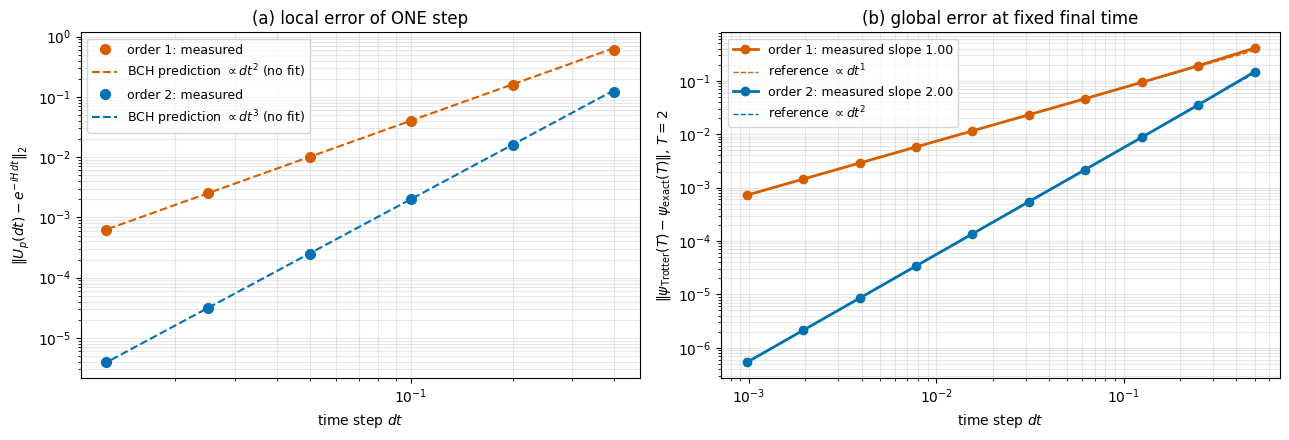

local error at dt = 0.4    : order 1 measured 5.973e-01 vs BCH 6.444e-01 (ratio 0.927) | order 2 measured 1.210e-01 vs BCH 1.287e-01 (ratio 0.940)
local error at dt = 0.0125 : order 1 measured 6.292e-04 vs BCH 6.293e-04 (ratio 1.000) | order 2 measured 3.927e-06 vs BCH 3.928e-06 (ratio 1.000)
global slopes: order 1 -> 1.00 (expected 1),  order 2 -> 2.00 (expected 2)
global error at dt = 0.0156: order 1 1.16e-02,  order 2 1.36e-04


In [22]:
# ==============================================================================
# EXPERIMENT 6: Trotter error versus dt -- local (one step, operator norm) and global (state at fixed T)
# ==============================================================================
op_norm = lambda M: float(jnp.linalg.norm(M, 2))                                # largest singular value

# --- BCH predictions for the local error (leading order) ---------------------
pref1 = 0.5 * op_norm(comm(H_even, H_odd))
pref2 = op_norm(-comm(H_even, comm(H_even, H_odd)) / 24 + comm(H_odd, comm(H_odd, H_even)) / 12)

dts_loc = np.array([0.4, 0.2, 0.1, 0.05, 0.025, 0.0125])
loc = {1: [], 2: []}
for dt_ in dts_loc:
    U_ex = propagator_eigh(E, V, dt_)
    for order in (1, 2):
        loc[order].append(op_norm(trotter_step_unitary(bonds, N, dt_, order) - U_ex))

# --- global error at fixed final time -----------------------------------------
T_CONV = 2.0
psi_ref = evolve_eigh(E, V, psi0, T_CONV)
n_list = np.array([2 ** k for k in range(2, 12)])                               # 4 ... 2048 steps
dts_glob = T_CONV / n_list
glob = {1: [], 2: []}
for n in n_list:
    for order in (1, 2):
        U_step = trotter_step_unitary(bonds, N, T_CONV / n, order)
        glob[order].append(float(jnp.linalg.norm(evolve_trotter(U_step, psi0, int(n))[-1] - psi_ref)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for order, col, pref, p in ((1, C_ORANGE, pref1, 2), (2, C_BLUE, pref2, 3)):
    ax.loglog(dts_loc, loc[order], "o", color=col, ms=7, label=f"order {order}: measured")
    ax.loglog(dts_loc, pref * dts_loc ** p, "--", color=col, lw=1.5, label=rf"BCH prediction $\propto dt^{p}$ (no fit)")
ax.set_xlabel(r"time step $dt$"); ax.set_ylabel(r"$\|U_p(dt)-e^{-iH\,dt}\|_2$"); ax.set_title("(a) local error of ONE step")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")

ax = axes[1]
slopes_trot = {}
for order, col in ((1, C_ORANGE), (2, C_BLUE)):
    errs = np.array(glob[order])
    good = errs < 0.1                                                           # asymptotic regime only
    slopes_trot[order] = np.polyfit(np.log(dts_glob[good]), np.log(errs[good]), 1)[0]
    ax.loglog(dts_glob, errs, "o-", color=col, lw=2, label=f"order {order}: measured slope {slopes_trot[order]:.2f}")
    ax.loglog(dts_glob, errs[-1] * (dts_glob / dts_glob[-1]) ** order, "--", color=col, lw=1, label=rf"reference $\propto dt^{order}$")
ax.set_xlabel(r"time step $dt$"); ax.set_ylabel(rf"$\|\psi_{{\rm Trotter}}(T)-\psi_{{\rm exact}}(T)\|$, $T={T_CONV:g}$")
ax.set_title("(b) global error at fixed final time")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

for k_dt in (0, len(dts_loc) - 1):
    d_ = dts_loc[k_dt]
    print(f"local error at dt = {d_:<7}: order 1 measured {loc[1][k_dt]:.3e} vs BCH {pref1*d_**2:.3e} (ratio {loc[1][k_dt]/(pref1*d_**2):.3f}) | "
          f"order 2 measured {loc[2][k_dt]:.3e} vs BCH {pref2*d_**3:.3e} (ratio {loc[2][k_dt]/(pref2*d_**3):.3f})")
print(f"global slopes: order 1 -> {slopes_trot[1]:.2f} (expected 1),  order 2 -> {slopes_trot[2]:.2f} (expected 2)")
print(f"global error at dt = {dts_glob[5]:.4f}: order 1 {glob[1][5]:.2e},  order 2 {glob[2][5]:.2e}")
assert abs(loc[1][-1] / (pref1 * dts_loc[-1] ** 2) - 1) < 0.05 and abs(loc[2][-1] / (pref2 * dts_loc[-1] ** 3) - 1) < 0.05
assert abs(slopes_trot[1] - 1) < 0.15 and abs(slopes_trot[2] - 2) < 0.15

**Interpretation.**

* *(a)* The dashed lines are **not fits**: they are the leading BCH terms, commutator norms included. For small $dt$ the measured one-step errors fall on top of them — the printed
  ratio measured/predicted is $1.000$ at $dt=0.0125$ for both orders; at $dt=0.4$ it has dropped to about $0.93$, which is the neglected next order of the BCH series becoming visible.
  The size of the Trotter error is governed by commutators — nothing else (rigorous commutator bounds for product formulas of any order: Childs *et al.* 2021).
* *(b)* One power of $dt$ is lost on the way from one step to $n=T/dt$ steps, Eq. (12): the global error is first order for Lie–Trotter and second order for Strang, with measured slopes close to 1 and 2.
  At the same $dt$ the second-order scheme is more accurate by orders of magnitude, at essentially the same cost, so for a time-independent Hamiltonian the first-order formula has no place in production runs.

### 7.8 Error growth in time, conserved quantities, and a comparison with RK4

We now fix $dt=0.05$ and watch the error *during* a long evolution, $t\le30$. For Trotter we record the state error, the deviation of the energy $\langle H\rangle_t-\langle H\rangle_0$ and the deviation of the norm from 1. For comparison: RK4 with the same $dt$.
Equation (12) says the state error can grow at most linearly, $\le(t/dt)\times$(local error); and the effective-Hamiltonian argument of Section 7.3 says the energy error should stay bounded.

Trotter 1 : state error at t=3: 4.00e-02, at t=30: 3.68e-02 | max energy error 1.51e-02 | max norm error 9.54e-14
Trotter 2 : state error at t=3: 2.17e-03, at t=30: 1.91e-02 | max energy error 1.29e-03 | max norm error 4.70e-13
RK4       : state error at t=3: 7.91e-03, at t=30: 7.74e-02 | max energy error 3.86e-01 | max norm error 2.13e-02


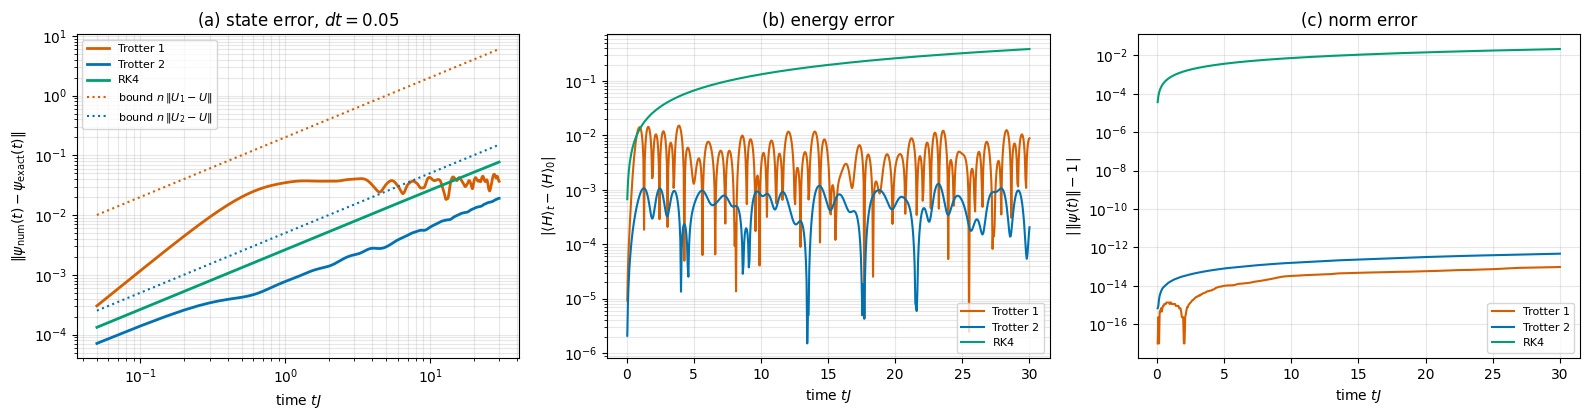

In [23]:
# ==============================================================================
# EXPERIMENT 7: error versus time at fixed dt
# ==============================================================================
DT, T_LONG = 0.05, 30.0
n_long = int(round(T_LONG / DT))
ts_long = jnp.arange(n_long + 1) * DT
exact_long = evolve_eigh_many(E, V, psi0, ts_long)                          # reference trajectory (T, D)
E0 = float(expectation(psi0, H))
energy_of = jax.vmap(expectation, in_axes=(0, None))                        # <H> for every state of a trajectory

trajs = {"Trotter 1": evolve_trotter(trotter_step_unitary(bonds, N, DT, 1), psi0, n_long),
         "Trotter 2": evolve_trotter(trotter_step_unitary(bonds, N, DT, 2), psi0, n_long),
         "RK4": integrate(rk4_step, H, psi0, DT, n_long)}
cols = {"Trotter 1": C_ORANGE, "Trotter 2": C_BLUE, "RK4": C_GREEN}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for name, traj in trajs.items():
    err_state = jnp.linalg.norm(traj - exact_long, axis=1)
    err_energy = jnp.abs(energy_of(traj, H) - E0)
    err_norm = jnp.abs(jnp.linalg.norm(traj, axis=1) - 1.0)
    axes[0].loglog(ts_long[1:], err_state[1:], color=cols[name], lw=2, label=name)
    axes[1].semilogy(ts_long[1:], err_energy[1:] + 1e-17, color=cols[name], lw=1.5, label=name)
    axes[2].semilogy(ts_long[1:], err_norm[1:] + 1e-17, color=cols[name], lw=1.5, label=name)
    print(f"{name:10s}: state error at t=3: {float(err_state[60]):.2e}, at t=30: {float(err_state[-1]):.2e} | "
          f"max energy error {float(jnp.max(err_energy)):.2e} | max norm error {float(jnp.max(err_norm)):.2e}")
# linear bounds n * (local error), Eq. (12)
for order, name in ((1, "Trotter 1"), (2, "Trotter 2")):
    local = op_norm(trotter_step_unitary(bonds, N, DT, order) - propagator_eigh(E, V, DT))
    axes[0].loglog(ts_long[1:], (ts_long[1:] / DT) * local, ":", color=cols[name], lw=1.5, label=rf"bound $n\,\|U_{order}-U\|$")
axes[0].set_title(rf"(a) state error, $dt={DT}$"); axes[0].set_ylabel(r"$\|\psi_{\rm num}(t)-\psi_{\rm exact}(t)\|$")
axes[1].set_title("(b) energy error"); axes[1].set_ylabel(r"$|\langle H\rangle_t-\langle H\rangle_0|$")
axes[2].set_title("(c) norm error"); axes[2].set_ylabel(r"$|\,\|\psi(t)\|-1\,|$")
for ax in axes:
    ax.set_xlabel(r"time $tJ$"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.**

* *(a)* Both Trotter errors stay below the dotted bounds $n\|U_p-U\|$ of Eq. (12), but they behave differently. The second-order error grows **linearly** in time (slope 1 on the log–log plot,
  from $2.2\cdot10^{-3}$ at $t=3$ to $1.9\cdot10^{-2}$ at $t=30$), while the first-order error grows only up to $t\approx1$ and then stays at about $4\cdot10^{-2}$ for the rest of the run. The reason lies in $H_{\rm eff}$ of Section 7.3. Its $O(dt)$
  correction $-\tfrac{i\,dt}{2}[H_B,H_A]$ has vanishing diagonal elements $\langle n|i[H_B,H_A]|n\rangle$ in the real eigenvectors of the real symmetric $H$ (both orderings of the product give the same
  real number), so it shifts no energy at first order. It only tilts the eigenvectors by $O(dt)$, which costs a bounded error; the phases drift only through the $O(dt^2)$ terms, as in the
  second-order scheme. The bound (12) assumes the worst case at every step and is far from tight here. Rule of thumb: for a target accuracy $\delta$ at time $t$ with a second-order scheme, choose $dt\propto\sqrt{\delta/t}$.
* *(b)* The Trotter energy error **does not grow**: it oscillates around a constant of order $dt$ (order 1) or $dt^2$ (order 2), as predicted by the effective-Hamiltonian argument. The RK4 energy error starts out comparable to the Trotter errors,
  but it *drifts* monotonically upwards, leaves both Trotter bands within the first time unit and ends up, at $t=30$, more than an order of magnitude above the first-order Trotter error (compare the printed maxima).
* *(c)* The norm is conserved to round-off by both Trotter schemes ($\sim10^{-13}$, slowly accumulating round-off), while RK4 loses norm steadily — a couple of per cent by $t=30$ at this $dt$, small but systematic.

A remark on the comparison: RK4 is a *fourth*-order method and we are running it against first- and second-order ones, so one would expect it to win on accuracy. At $dt=0.05$ it does beat first-order Trotter, but it does
**not** beat the Strang splitting: the printed state errors put Trotter 2 below RK4 both at $t=3$ and at $t=30$. The reason is the prefactor — the RK4 error term involves the fifth power of $H$, and $\max_n|E_n|\approx10$ here.
Trotterization anyway does not have to win on the order of accuracy (fourth-order
splittings exist if needed). It wins on **structure** — exact unitarity, no stability limit, bounded energy error — and, decisively, on the fact that it only ever needs exponentials of *small* matrices. That property is what will scale.

> **Physics insight.** A Trotterised evolution is the *exact* evolution of a periodically driven system in which $H_{\rm even}$ and $H_{\rm odd}$ are switched on alternately. For small $dt$ this driven system behaves like
> $H_{\rm eff}\approx H$. This is precisely how a "digital quantum simulator" implements a Hamiltonian it does not natively have.

### 7.9 A conservation law as a free diagnostic

If an operator $Q$ commutes with *every bond term* $h_{j,j+1}$, it commutes with every factor of the Trotter step, so it is conserved **exactly** by the Trotterised dynamics, for any $dt$. Example: the XXZ chain conserves the total magnetisation
$S^z_{\rm tot}=\sum_jZ_j$ (notebook 03), and each bond $J(XX+YY)+J_{zz}ZZ$ conserves it separately. Starting from the Néel state $|{\uparrow\downarrow\uparrow\downarrow}\cdots\rangle$ with $\langle S^z_{\rm tot}\rangle=0$, the Trotter evolution must keep
it at zero to round-off even when $dt$ is far too large for the state to be accurate. If it does not, the bug is in the code, whatever the step size.

In [24]:
# ==============================================================================
# CHECKPOINT 9: XXZ chain -- the total magnetisation is conserved exactly by the Trotter step, for any dt
# ==============================================================================
xxz = dict(Jxx=1.0, Jyy=1.0, Jzz=0.5, hx=0.0, hy=0.0, hz=0.0)
bonds_xxz = bond_hamiltonians(N, **xxz)
neel = basis_state([j % 2 for j in range(N)])                              # |up down up down ...>
traj_xxz = evolve_trotter(trotter_step_unitary(bonds_xxz, N, 0.5, 2), neel, 40)      # dt = 0.5: deliberately coarse
sz_tot = ((jnp.abs(traj_xxz) ** 2) @ ZTAB).sum(axis=1)                     # <sum_j Z_j>(t)
stagger = ((jnp.abs(traj_xxz) ** 2) @ ZTAB) @ jnp.array([(-1.0) ** j for j in range(N)]) / N
err_state_xxz = float(jnp.linalg.norm(traj_xxz[-1] - expm(-1j * 20.0 * build_hamiltonian_dense(N, **xxz)) @ neel))
print(f"max |<S^z_tot>(t)| over 40 steps of dt=0.5 : {float(jnp.max(jnp.abs(sz_tot))):.1e}   (conserved exactly)")
print(f"staggered magnetisation: {float(stagger[0]):.3f} -> {float(stagger[-1]):.3f}   (the state itself evolves non-trivially)")
print(f"state error at t=20 with this coarse dt    : {err_state_xxz:.2f}   (large -- yet the symmetry is intact)")
assert float(jnp.max(jnp.abs(sz_tot))) < 100 * TOL

max |<S^z_tot>(t)| over 40 steps of dt=0.5 : 4.4e-16   (conserved exactly)
staggered magnetisation: 1.000 -> 0.062   (the state itself evolves non-trivially)
state error at t=20 with this coarse dt    : 1.65   (large -- yet the symmetry is intact)


The state is badly wrong at this step size (error of order one) — yet $\langle S^z_{\rm tot}\rangle$ stays at zero to round-off: symmetries shared by all bond terms survive Trotterization exactly.

### 7.10 What each method conserves

"Exactly" below means to round-off, for *any* step size; "$O(dt^p)$, bounded" means the quantity oscillates in a band of that width and does not drift.
$Q$ stands for any operator that commutes with every bond term, such as $S^z_{\rm tot}$ in the XXZ chain. All statements refer to the measured quantities of
Sections 6.3 and 7.8.

| method | norm $\langle\psi\vert\psi\rangle$ | energy $\langle H\rangle$ | symmetry $\langle Q\rangle$ | step restriction |
|---|---|---|---|---|
| eigendecomposition, `expm` | exact | exact | exact | none (no time step at all) |
| explicit Euler | grows, Eq. (6) | grows | not conserved | none works |
| RK4 | decays by $1-y^6/144$ per step, $y=E_n\,dt$ | drifts monotonically | not conserved | $dt\,\Vert H\Vert\le2\sqrt2$, Eq. (7a) |
| Trotter, order 1 | exact | $O(dt)$, bounded | exact | none |
| Trotter, order 2 (Strang) | exact | $O(dt^2)$, bounded | exact | none |

The two right-hand columns are what "structure-preserving" means, and they are the reason the splitting methods took over quantum dynamics even though RK4
has the higher order of accuracy. The mechanism is the same in all three cases: the Trotter step is a product of exact unitaries, so it *is* the exact
propagator of a nearby Hermitian $H_{\rm eff}$ (Section 7.3) — and an exact propagator conserves norms and symmetries whether or not it propagates the
Hamiltonian we asked for.

## 8. Physics: a quantum quench in the transverse-field Ising chain

### 8.1 The protocol

We now use the machinery for a physics question, with $N=10$ spins ($D=1024$). The chain is prepared in $|\psi_0\rangle=|{\uparrow\uparrow\cdots\uparrow}\rangle$, a ground state of the classical Ising chain ($h=0$), and at $t=0$ the transverse field is switched on:
the state evolves with $H=-J\sum_jZ_jZ_{j+1}-h\sum_jX_j$. This is a **quantum quench**. The infinite chain has a quantum phase transition at $h=J$ between a ferromagnet ($h<J$) and a paramagnet ($h>J$) — you saw its
finite-size signature in the gap in notebook 03 — so we compare three quenches: within the ferromagnetic phase ($h=0.5J$), to the critical point ($h=J$), and across it ($h=2J$). Experiments of exactly this type are performed with
trapped-ion chains and Rydberg-atom arrays. We record

* the magnetisation $m_z(t)=\frac1N\sum_j\langle Z_j\rangle$: does the order survive?
* connected correlations $C^{\alpha\alpha}_{0j}(t)=\langle\sigma^\alpha_0\sigma^\alpha_j\rangle-\langle\sigma^\alpha_0\rangle\langle\sigma^\alpha_j\rangle$ ($\alpha=x,z$) between the first spin and spin $j$. They vanish in a product state; how fast do they build up at distance $j$?
* the Loschmidt echo $\mathcal L(t)=|\langle\psi_0|\psi(t)\rangle|^2$, the probability of finding the system back in its initial state.

**Method.** Exact evolution on a time grid (`evolve_eigh_many`), cross-checked against second-order Trotter. **Observables.** Everything diagonal in $z$ comes from the probabilities $|\psi_s|^2$ and the $z$-table. For the $x$-correlations we use a
change of basis: the matrix $W=(X+Z)/\sqrt2$ is Hermitian, unitary, and satisfies $WXW=Z$ (its columns are the eigenvectors of $X$). Hence $\langle\psi|X_iX_j|\psi\rangle=\langle\psi'|Z_iZ_j|\psi'\rangle$ with $|\psi'\rangle=W^{\otimes N}|\psi\rangle$:
rotate the state once, then use the $z$-table again. The echo is simply $|\psi_{0}(t)|^2$, the probability of the basis state with flat index 0.

In [25]:
# ==============================================================================
# PARAMETERS of the quench experiment
# ==============================================================================
N_Q = 10                           # chain length (D = 1024; dense eigh takes about a second)
J_Q = 1.0                          # Ising coupling
H_FIELDS = (0.5, 1.0, 2.0)         # post-quench transverse fields: ferromagnetic side, critical, paramagnetic side
T_Q, NT_Q = 6.0, 481               # final time and number of time points
DT_TROTTER = 0.05                  # step of the second-order Trotter cross-check

ts_q = jnp.linspace(0.0, T_Q, NT_Q)
ZTAB_Q = z_table(N_Q)
psi0_q = basis_state([0] * N_Q)
W1 = (X + Z) / jnp.sqrt(2.0)
W_all = jnp.eye(1, dtype=CDTYPE)
for _ in range(N_Q):
    W_all = jnp.kron(W_all, W1)    # W (x) W (x) ... (x) W : z-basis <-> x-basis on every spin


def connected_correlations(p, ztab, ref):
    """C_j(t) = <Z_ref Z_j> - <Z_ref><Z_j> from Born probabilities p (T, D) and the z-table (D, N).  Returns (T, N)."""
    m = p @ ztab                                        # (T, N)  <Z_j>
    zz = p @ (ztab[:, [ref]] * ztab)                    # (T, N)  <Z_ref Z_j>
    return zz - m[:, [ref]] * m


quench = {}
t_start = time.perf_counter()
for hq in H_FIELDS:
    Hq = build_hamiltonian_dense(N_Q, 0.0, 0.0, -J_Q, -hq, 0.0, 0.0)
    Eq, Vq = diagonalize(Hq)
    states = evolve_eigh_many(Eq, Vq, psi0_q, ts_q)                     # (T, D) exact
    p_z = jnp.abs(states) ** 2
    p_x = jnp.abs(states @ W_all.T) ** 2                                # probabilities in the x-basis
    # second-order Trotter cross-check of the magnetisation
    n_tr = int(round(T_Q / DT_TROTTER))
    U_tr = trotter_step_unitary(bond_hamiltonians(N_Q, 0.0, 0.0, -J_Q, -hq, 0.0, 0.0), N_Q, DT_TROTTER, 2)
    traj_tr = evolve_trotter(U_tr, psi0_q, n_tr)
    quench[hq] = dict(mz=(p_z @ ZTAB_Q).mean(axis=1), mz_sites=p_z @ ZTAB_Q,
                      czz=connected_correlations(p_z, ZTAB_Q, 0), cxx=connected_correlations(p_x, ZTAB_Q, 0),
                      echo=p_z[:, 0], echo_flipped=p_z[:, -1],
                      mz_trotter=((jnp.abs(traj_tr) ** 2) @ ZTAB_Q).mean(axis=1),
                      energy_drift=float(jnp.max(jnp.abs(jax.vmap(expectation, in_axes=(0, None))(states[::40], Hq) - expectation(psi0_q, Hq)))))
    quench[hq]["mz"].block_until_ready()
print(f"three quenches (N = {N_Q}): {time.perf_counter() - t_start:.1f} s in total")
for hq in H_FIELDS:
    print(f"h = {hq}: max |<H>_t - <H>_0| along the exact trajectory = {quench[hq]['energy_drift']:.1e}")
    assert quench[hq]["energy_drift"] < 1e3 * TOL

three quenches (N = 10): 7.0 s in total
h = 0.5: max |<H>_t - <H>_0| along the exact trajectory = 2.1e-14
h = 1.0: max |<H>_t - <H>_0| along the exact trajectory = 7.1e-15
h = 2.0: max |<H>_t - <H>_0| along the exact trajectory = 1.2e-14


### 8.2 Melting of the magnetic order

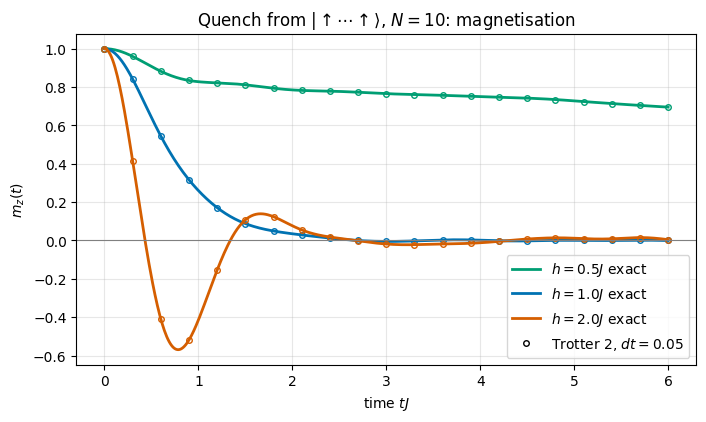

h = 0.5: max |m_z(Trotter 2) - m_z(exact)| = 1.2e-04;   m_z at t = 6: +0.695;   minimum of m_z: +0.695
h = 1.0: max |m_z(Trotter 2) - m_z(exact)| = 3.8e-04;   m_z at t = 6: -0.000;   minimum of m_z: -0.005
h = 2.0: max |m_z(Trotter 2) - m_z(exact)| = 2.9e-04;   m_z at t = 6: +0.004;   minimum of m_z: -0.569


In [26]:
# ==============================================================================
# FIGURE: magnetisation dynamics for the three quenches (lines: exact; circles: 2nd-order Trotter)
# ==============================================================================
ts_tr = np.arange(int(round(T_Q / DT_TROTTER)) + 1) * DT_TROTTER
fig, ax = plt.subplots(figsize=(8, 4.3))
for hq, col in zip(H_FIELDS, (C_GREEN, C_BLUE, C_ORANGE)):
    ax.plot(ts_q, quench[hq]["mz"], color=col, lw=2, label=rf"$h={hq}J$ exact")
    ax.plot(ts_tr[::6], quench[hq]["mz_trotter"][::6], "o", color=col, ms=4, mfc="none")
ax.plot([], [], "o", color="k", ms=4, mfc="none", label=rf"Trotter 2, $dt={DT_TROTTER}$")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel(r"time $tJ$"); ax.set_ylabel(r"$m_z(t)$"); ax.set_title(rf"Quench from $|\uparrow\cdots\uparrow\rangle$, $N={N_Q}$: magnetisation")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# quantitative agreement Trotter vs exact on the common time points (every 4th exact point = every Trotter point)
stride = int(round(DT_TROTTER / (T_Q / (NT_Q - 1))))
for hq in H_FIELDS:
    dev = float(jnp.max(jnp.abs(quench[hq]["mz_trotter"] - quench[hq]["mz"][::stride])))
    print(f"h = {hq}: max |m_z(Trotter 2) - m_z(exact)| = {dev:.1e};   m_z at t = {T_Q:g}: {float(quench[hq]['mz'][-1]):+.3f};   minimum of m_z: {float(jnp.min(quench[hq]['mz'])):+.3f}")
    assert dev < 5e-3

**Interpretation.** Second-order Trotter with $dt=0.05$ reproduces the exact magnetisation to a few $10^{-4}$ (printed above) — more than enough for plotting — so both methods agree on the physics:

* $h=0.5J$ (quench inside the ferromagnetic phase): the magnetisation decays only slowly; at $t=6/J$ most of the order is still there. In the infinite chain the decay is known to be exponential with a rate that becomes very small for small $h$.
* $h=J$ (to the critical point): the order melts completely within $t\approx3/J$.
* $h=2J$ (across the transition): the field dominates; spins precess (first zero near $\pi/(4h)\approx0.4$, as for a free spin in Section 4.3), $m_z$ overshoots to negative values and the oscillation is damped by the interactions.

The damping is remarkable: the system is isolated and its evolution is unitary, yet a local quantity relaxes as if there were friction. The "bath" is the rest of the chain: information about the initial state spreads into
correlations among many spins, which a local probe cannot see. How fast it spreads is our next question.

### 8.3 The light cone of correlations

In a non-relativistic lattice model nothing forbids instantaneous signalling a priori. Nevertheless, Lieb and Robinson proved in 1972 that for short-range interactions
a commutator of operators separated by a distance $d$ obeys $\|[A_0(t),B_d]\|\le c\,\|A\|\,\|B\|\,e^{-(d-v_{\rm LR}t)/\xi}$: outside a cone $d>v_{\rm LR}t$ all
influence is exponentially small. That is an **existence theorem with a bound**, and the bound is loose — $v_{\rm LR}$ is built from sums of coupling constants and
typically overestimates what one sees by a factor of a few. It does not by itself tell us how fast correlations actually travel.

The velocity that shows up in a measurement is a different, model-specific quantity. For a quench there is an intuitive picture (Calabrese and Cardy): the initial state has a
high energy relative to the new ground state and acts as a source of *pairs of quasi-particles* flying apart with opposite momenta; two spins at distance $d$ become
correlated when they are hit by the two partners of a pair emitted half-way between them, i.e. at $t\approx d/(2v_{\max})$, where $v_{\max}$ is the largest **group
velocity** of a single quasi-particle. For the TFIM the quasi-particle energies are known exactly (quoted; see Pfeuty, Sachdev): $\epsilon_k=2\sqrt{J^2+h^2-2Jh\cos k}$,
whose maximal group velocity is $v_{\max}=\max_k|d\epsilon_k/dk|=2\min(J,h)$ lattice sites per unit time. So the prediction for the *front of the correlations* is the
parameter-free number $2v_{\max}=4\min(J,h)$ — a *physical* velocity. The Lieb–Robinson theorem only guarantees that some finite $v_{\rm LR}$ exists and bounds the
spreading of a single Heisenberg operator from above, $v_{\rm LR}\ge v_{\max}$; the factor 2 in the correlation cone is the pair mechanism, and it is what we test here.

Such a light cone of correlations, carried by quasi-particle pairs, was observed with ultracold atoms in an optical lattice by Cheneau *et al.* (2012).

We plot $|C_{0j}(t)|$ on a logarithmic colour scale and overlay the line $j=2v_{\max}t$. We choose spin 0 (the left end) as the reference to have the longest possible
distances in our short chain (a reference at the centre of the chain gives velocities within about ten per cent of these, but only half the range of distances).

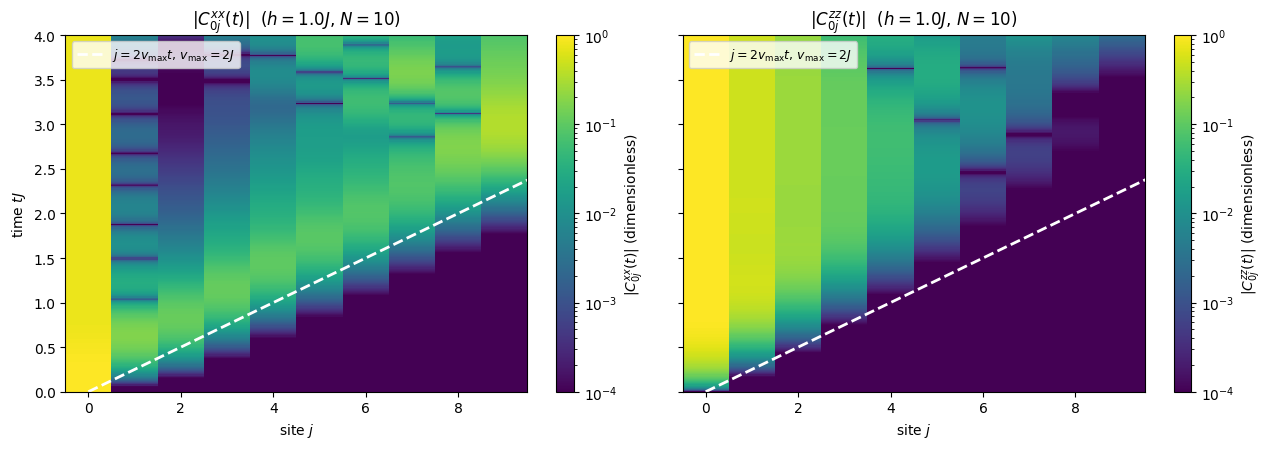

arrival times of the xx-correlation front at distance j = 1..9 (half of the first peak): [0.4   0.575 0.875 1.162 1.438 1.713 1.988 2.4   2.638]
front velocity, half-of-peak criterion (j = 2..8): 3.39 sites per unit time
front velocity, threshold |C^xx| > 0.01              : 3.69 sites per unit time
front velocity, threshold |C^xx| > 0.001             : 3.96 sites per unit time
front velocity, threshold |C^xx| > 0.0001            : 4.26 sites per unit time
quasi-particle prediction                          : 2 v_max = 4 sites per unit time
max |C^xx_0j| at t = 0 over the genuine distances j = 1..9: 1.6e-16  (product state: no correlations)
   the column j = 0 is not a correlation but the on-site variance C_00 = <X_0^2> - <X_0>^2 = 1.000


In [27]:
# ==============================================================================
# FIGURE: connected correlations |C_0j(t)| after the quench to h = J  (log colour scale) + light-cone line
# ==============================================================================
from matplotlib.colors import LogNorm

h_lc = 1.0
v_max = 2 * min(J_Q, h_lc)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, key_c, lab in zip(axes, ("cxx", "czz"), (r"$|C^{xx}_{0j}(t)|$", r"$|C^{zz}_{0j}(t)|$")):
    Cabs = np.abs(np.asarray(quench[h_lc][key_c])) + 1e-16
    im = ax.pcolormesh(np.arange(N_Q), np.asarray(ts_q), Cabs, shading="nearest", cmap="viridis", norm=LogNorm(1e-4, 1.0))
    ax.plot(2 * v_max * np.asarray(ts_q), np.asarray(ts_q), "--", color="white", lw=2, label=rf"$j=2v_{{\max}}t$, $v_{{\max}}={v_max:g}J$")
    ax.set_xlim(-0.5, N_Q - 0.5); ax.set_ylim(0, 4.0)
    ax.set_xlabel("site $j$"); ax.set_title(lab + rf"  ($h={h_lc}J$, $N={N_Q}$)")
    ax.legend(loc="upper left", fontsize=9)
    fig.colorbar(im, ax=ax, label=lab + " (dimensionless)")
axes[0].set_ylabel(r"time $tJ$")
plt.tight_layout(); plt.show()

# ------------------------------------------------------------------------------
# front velocity: the "arrival time" at distance j is the first time |C^xx_0j| exceeds a threshold,
# and the fitted velocity DEPENDS ON THE THRESHOLD -- that dependence is the whole point of this cell.
# ------------------------------------------------------------------------------
Cx = np.abs(np.asarray(quench[h_lc]["cxx"]))
dist = np.arange(1, N_Q)
sel = (dist >= 2) & (dist <= N_Q - 2)                                                        # skip nearest neighbour and the far end


def front_velocity(arrival):
    """Sites per unit time from a straight-line fit of the arrival time against the distance (inverse slope)."""
    return 1.0 / np.polyfit(dist[sel], np.asarray(arrival)[sel], 1)[0]


# (a) relative criterion: half of the height of the first local maximum at that distance
arrival_half = []
for j in range(1, N_Q):
    a = Cx[:, j]
    k_peak = np.argmax((a[1:-1] > a[:-2]) & (a[1:-1] >= a[2:]) & (a[1:-1] > 1e-3)) + 1      # first local maximum
    arrival_half.append(float(ts_q[np.argmax(a >= 0.5 * a[k_peak])]))
print("arrival times of the xx-correlation front at distance j = 1..9 (half of the first peak):", np.round(arrival_half, 3))
print(f"front velocity, half-of-peak criterion (j = 2..{N_Q-2}): {front_velocity(arrival_half):.2f} sites per unit time")

# (b) fixed absolute thresholds, from a high (late arrival) to a low one (early arrival)
for thr in (1e-2, 1e-3, 1e-4):
    arrival_thr = [float(ts_q[np.argmax(Cx[:, j] >= thr)]) for j in range(1, N_Q)]
    print(f"front velocity, threshold |C^xx| > {thr:<6g}            : {front_velocity(arrival_thr):.2f} sites per unit time")
print(f"quasi-particle prediction                          : 2 v_max = {2*v_max:g} sites per unit time")
print(f"max |C^xx_0j| at t = 0 over the genuine distances j = 1..{N_Q-1}: {float(np.max(Cx[0, 1:])):.1e}  (product state: no correlations)")
print(f"   the column j = 0 is not a correlation but the on-site variance C_00 = <X_0^2> - <X_0>^2 = {float(Cx[0, 0]):.3f}")

**Interpretation.** The bright column at $j=0$ is not a correlation at all: it is the reference site itself, where $C_{00}=\langle(\sigma^\alpha_0)^2\rangle-\langle\sigma^\alpha_0\rangle^2$ is the on-site variance (equal to 1 in the initial state, as the printed number confirms). At every genuine distance $j\ge1$
both correlators vanish identically at $t=0$ and then fill a **cone**: outside the dashed line $j=2v_{\max}t$ the correlations are suppressed by many orders of magnitude (dark region) although every spin is coupled, through its neighbours, to every other one from the very first instant.
The $zz$ correlations live inside the same cone but build up more slowly behind the front. After $t\approx N/(2v_{\max})\approx2.5/J$ the front has reached the far end of the chain; what follows is finite-size physics (reflections).

**Reading the measured velocities.** There is no sharp front to measure: at distance $j$ the correlation rises smoothly from an exponentially
small tail to a value of order one, so *any* definition of "arrival" is a choice of threshold — and the fitted velocity moves with it, in a known direction. A **high**
threshold (our half-of-the-first-peak criterion, or $|C|>10^{-2}$) declares the arrival too late and therefore **under**estimates the velocity; a **low** threshold
triggers already on the tail and **over**estimates it. The printed numbers do exactly that: $3.4$, $3.7$, $4.0$, $4.3$ for the four criteria, bracketing the
parameter-free prediction $2v_{\max}=4J$. The correct statement is therefore that *the front velocity of the
$xx$-correlations is $4J$ to within the systematic uncertainty of the front definition, which at $N=10$ is some ten per cent.* Extracting a velocity better than that
needs a longer chain, or a fit to the whole space–time profile rather than to one contour of it — see
[notebook 15, Chapter 5](../ch05_ground_states_and_unitary_dynamics/15_quench_dynamics_spin_chains.ipynb), where the same bias is studied at several fields.

> **Common pitfall.** Quoting a light-cone velocity without quoting the threshold that defined the front is meaningless. Always vary the threshold and report the spread.

> **Physics insight.** The light cone is also the reason why time evolution is *hard* for cleverer classical methods: correlations — and with them entanglement — grow linearly in time after a quench. We will quantify this in
> [notebook 15, Chapter 5](../ch05_ground_states_and_unitary_dynamics/15_quench_dynamics_spin_chains.ipynb) and meet its consequences for matrix product states in [notebook 18, Chapter 7](../ch07_tensor_networks/18_mps_tebd.ipynb).

### 8.4 The Loschmidt echo

$\mathcal L(t)=|\langle\psi_0|e^{-iHt}|\psi_0\rangle|^2$ asks: what is the probability that the chain is found exactly in its initial configuration? In terms of the eigen-decomposition, $\langle\psi_0|\psi(t)\rangle=\sum_n|c_n|^2e^{-iE_nt}$ —
the echo is the squared modulus of the Fourier transform of the energy distribution of the initial state. Because *all* $N$ spins must return, $\mathcal L$ is exponentially small in $N$, and the natural quantity is the **rate function**
$\lambda(t)=-\frac1N\ln\mathcal L(t)$, which stays finite as $N\to\infty$.

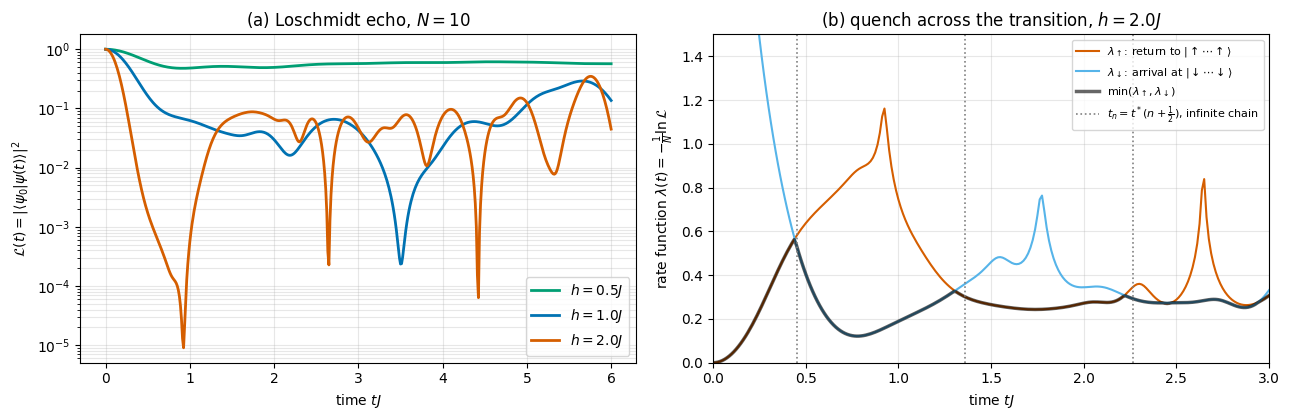

first crossings of lambda_up and lambda_down (N=10): [0.45  1.312 2.225]
critical times of the infinite chain t*(n+1/2)     : [0.453 1.36  2.267]
h = 0.5: minimum of the echo on (0, 6] = 4.77e-01
h = 1.0: minimum of the echo on (0, 6] = 2.36e-04
h = 2.0: minimum of the echo on (0, 6] = 9.07e-06


In [28]:
# ==============================================================================
# FIGURE: Loschmidt echo and rate function
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for hq, col in zip(H_FIELDS, (C_GREEN, C_BLUE, C_ORANGE)):
    axes[0].semilogy(ts_q, quench[hq]["echo"], color=col, lw=2, label=rf"$h={hq}J$")
axes[0].set_xlabel(r"time $tJ$"); axes[0].set_ylabel(r"$\mathcal{L}(t)=|\langle\psi_0|\psi(t)\rangle|^2$"); axes[0].set_title(f"(a) Loschmidt echo, $N={N_Q}$")
axes[0].legend(); axes[0].grid(alpha=0.3, which="both")

h_dq = 2.0
lam_up = -jnp.log(quench[h_dq]["echo"]) / N_Q                    # return to |up...up>
lam_dn = -jnp.log(quench[h_dq]["echo_flipped"] + 1e-300) / N_Q   # arrival at the OTHER ground state |down...down>
axes[1].plot(ts_q, lam_up, color=C_ORANGE, lw=1.5, label=r"$\lambda_\uparrow$: return to $|\uparrow\cdots\uparrow\rangle$")
axes[1].plot(ts_q, lam_dn, color=C_SKY, lw=1.5, label=r"$\lambda_\downarrow$: arrival at $|\downarrow\cdots\downarrow\rangle$")
axes[1].plot(ts_q, jnp.minimum(lam_up, lam_dn), color="k", lw=2.5, alpha=0.6, label=r"$\min(\lambda_\uparrow,\lambda_\downarrow)$")
t_star = np.pi / (2 * np.sqrt(h_dq ** 2 - J_Q ** 2))
for n_c in range(3):
    axes[1].axvline(t_star * (n_c + 0.5), color="gray", ls=":", lw=1.2, label=(r"$t_n=t^*(n+\frac{1}{2})$, infinite chain" if n_c == 0 else None))
axes[1].set_xlim(0, 3.0); axes[1].set_ylim(0, 1.5)
axes[1].set_xlabel(r"time $tJ$"); axes[1].set_ylabel(r"rate function $\lambda(t)=-\frac{1}{N}\ln\mathcal{L}$"); axes[1].set_title(rf"(b) quench across the transition, $h={h_dq}J$")
axes[1].legend(fontsize=8, loc="upper right"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

sign = np.sign(np.asarray(lam_up - lam_dn))
t_cross = np.asarray(ts_q)[1:][sign[1:] != sign[:-1]]
print("first crossings of lambda_up and lambda_down (N=10):", np.round(t_cross[:3], 3))
print("critical times of the infinite chain t*(n+1/2)     :", np.round([t_star * (n + 0.5) for n in range(3)], 3))
for hq in H_FIELDS:
    print(f"h = {hq}: minimum of the echo on (0, {T_Q:g}] = {float(jnp.min(quench[hq]['echo'])):.2e}")

**Interpretation.**

* *(a)* For the weak quench ($h=0.5J$) the state stays close to where it started: the echo remains of order one. For $h=J$ and $h=2J$ it collapses by many orders of magnitude within a time of order $1/J$: the initial state is a
  superposition of very many eigenstates, whose phases $e^{-iE_nt}$ run out of step. In a finite system they can re-phase later (partial revivals), but full recurrences take astronomically long times as $N$ grows.
* *(b)* For the quench across the critical point the rate function shows sharp structures. The TFIM has *two* degenerate symmetry-broken ground states at $h=0$, $|{\uparrow\cdots\uparrow}\rangle$ and $|{\downarrow\cdots\downarrow}\rangle$, and one can
  ask for the probability of being in either. The two rate functions **cross**, and the physical rate $\min(\lambda_\uparrow,\lambda_\downarrow)$ — the one that dominates as $N\to\infty$ — has a **kink** at each crossing: a non-analytic
  point *in time*, called a **dynamical quantum phase transition** by analogy with the non-analytic ground-state energy density at a quantum phase transition. For the infinite chain the critical times are known analytically (Heyl, Polkovnikov and Kehrein; quoted without proof):
  $t_n=t^*(n+\tfrac12)$ with $t^*=\pi/\big(2\sqrt{h^2-J^2}\big)$ for a quench from $h=0$. The first crossings of our 10-spin chain (printed above) already fall within a few per cent of these values (dotted lines); such kinks have been observed
  in a trapped-ion quantum simulator (Jurcevic *et al.*). No kinks occur for quenches that stay within the ferromagnetic phase.

**What the finite chain can and cannot show.** Be precise about what is a transition here. At any finite $N$, $\langle\psi_0|\psi(t)\rangle=\sum_n|c_n|^2e^{-iE_nt}$ is a
finite sum of exponentials: an entire function of $t$. Its modulus can come very close to zero but generically does not vanish, so $\lambda_\uparrow(t)$ is **analytic at every
time** — a chain of 10 spins has no dynamical phase transition, just as a finite lattice has no quantum phase transition (its ground-state energy is an analytic function of $h$). Two things are genuinely finite-$N$ objects in panel (b):
the sharp maxima of $\lambda_\uparrow$ (near-zeros of the echo, which turn into true zeros only as $N\to\infty$) and the kink of $\min(\lambda_\uparrow,\lambda_\downarrow)$,
which is put there by the $\min$ and not by the dynamics. What the finite chain *does* show is that the locations of these features converge quickly: at $N=10$ they already
sit within a few per cent of the infinite-chain times $t_n$. That is the standard way such statements are established numerically — locate the feature at several
$N$ and extrapolate, never claim the singularity itself from one finite system.

## 9. Memory and time cost of the textbook methods

Everything above ran in seconds — for $N\le10$. The cost scales with $N$ as follows, with $D=2^N$:

| object / operation | memory | time |
|---|---|---|
| state vector $\psi$ | $D=2^N$ numbers | — |
| dense $H$, $U(t)$, a Trotter layer, `site_operator` | $D^2=4^N$ numbers | — |
| `eigh`, `expm`, product of two dense matrices | several $D^2$ | $O(D^3)=O(8^N)$ |
| one dense matrix–vector product (one Euler/RK4 stage, one dense Trotter step) | $D^2$ | $O(D^2)=O(4^N)$ |

Adding **one** spin multiplies the memory by 4 and the diagonalisation time by 8. First the memory, in double precision (16 bytes per complex number):

In [29]:
# ==============================================================================
# COST 1: memory of a state vector versus a dense operator (CDTYPE: 16 bytes per number in double precision)
# ==============================================================================
def human(nbytes):
    """Format a number of bytes with a binary unit."""
    for unit in ("B", "KB", "MB", "GB", "TB", "PB"):
        if nbytes < 1024:
            return f"{nbytes:7.1f} {unit}"
        nbytes /= 1024
    return f"{nbytes:7.1f} EB"


itemsize = np.dtype(CDTYPE).itemsize
print(f"{'N':>3} {'D = 2^N':>10} {'state vector':>14} {'dense operator':>16}")
for n in (8, 10, 12, 14, 16, 20, 24, 30):
    print(f"{n:>3} {2**n:>10} {human(itemsize * 2**n):>14} {human(itemsize * 4**n):>16}")

  N    D = 2^N   state vector   dense operator
  8        256         4.0 KB           1.0 MB
 10       1024        16.0 KB          16.0 MB
 12       4096        64.0 KB         256.0 MB
 14      16384       256.0 KB           4.0 GB
 16      65536         1.0 MB          64.0 GB
 20    1048576        16.0 MB          16.0 TB
 24   16777216       256.0 MB           4.0 PB
 30 1073741824        16.0 GB          16.0 EB


At $N=14$ a *single* dense operator needs 4 GB, and `eigh`/`expm` need several of them as workspace; $N=16$ asks for 64 GB per matrix. The state vector, by contrast, remains harmless far longer: 16 MB at $N=20$, 16 GB at $N=30$.
**The memory goes into the operators; the state itself stays small.**

Now the time. We measure `eigh`, `expm`, and a single dense matrix–vector product for growing $N$. Each function is called once for warm-up/compilation and then timed; the largest sizes are timed once,
and the matrix–vector product — which takes microseconds, i.e. the same order as the measurement noise — is timed as the *best of 50 repetitions*.
Absolute numbers depend on your machine and its load; the *ratios* between consecutive $N$ are the message.

N =  4 (D =    16):  eigh   0.0002 s | expm   0.0001 s | dense matvec 1.89e-05 s


N =  6 (D =    64):  eigh   0.0008 s | expm   0.0013 s | dense matvec 2.80e-05 s
N =  8 (D =   256):  eigh   0.0199 s | expm   0.0161 s | dense matvec 1.18e-04 s


N =  9 (D =   512):  eigh   0.1128 s | expm   0.1404 s | dense matvec 3.59e-04 s


N = 10 (D =  1024):  eigh   1.2039 s | expm   1.0892 s | dense matvec 6.19e-04 s


N = 11 (D =  2048):  eigh   8.0242 s | expm      nan s | dense matvec 2.88e-03 s


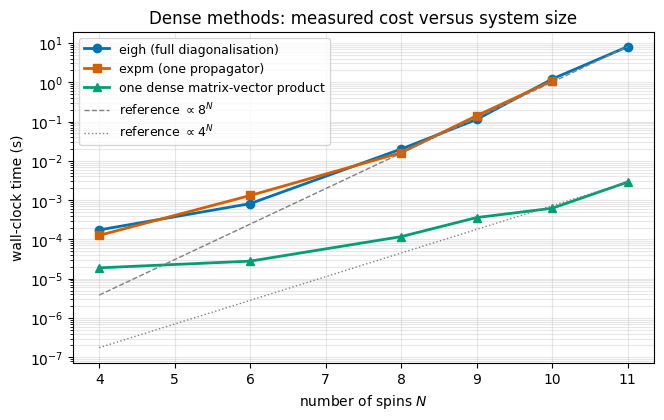

eigh: time(N=11) / time(N=10) = 6.7   (asymptotically 8 per added spin)
   extrapolated eigh time at N = 12: ~     64.2 s =     1.07 min =   0.0178 h
   extrapolated eigh time at N = 14: ~ 4.11e+03 s =     68.5 min =     1.14 h
   extrapolated eigh time at N = 16: ~ 2.63e+05 s = 4.38e+03 min =       73 h


In [30]:
# ==============================================================================
# COST 2: measured wall-clock time of the dense building blocks versus N
# ==============================================================================
def timed(fn, *args, warmup=True, reps=1):
    """Wall-clock time of fn(*args) in seconds, waiting for the asynchronous result (block_until_ready).

    With `reps` > 1 the call is repeated and the SMALLEST time is returned. Noise (other processes, caches,
    CPU frequency) can only ever make a run slower, so for sub-millisecond calls the minimum of several
    repetitions is a far more stable estimate than a single measurement.
    """
    if warmup:
        jax.block_until_ready(fn(*args))
    best = np.inf
    for _ in range(reps):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(*args))
        best = min(best, time.perf_counter() - t0)
    return best


matvec = jax.jit(lambda A, v: A @ v)
Ns_cost = [4, 6, 8, 9, 10, 11]
t_eigh, t_expm, t_mv = [], [], []
for n in Ns_cost:
    Hn = build_hamiltonian_dense(n, 0.0, 0.0, -1.0, -1.0, 0.0, 0.0)
    vn = basis_state([0] * n)
    big = n >= 11
    t_eigh.append(timed(jnp.linalg.eigh, Hn, warmup=not big))
    t_expm.append(timed(expm, -0.1j * Hn, warmup=not big) if n <= 10 else np.nan)
    t_mv.append(timed(matvec, Hn, vn, reps=50))       # microseconds: take the best of 50 to beat the noise
    print(f"N = {n:2d} (D = {2**n:5d}):  eigh {t_eigh[-1]:8.4f} s | expm {t_expm[-1]:8.4f} s | dense matvec {t_mv[-1]:.2e} s")
    del Hn

fig, ax = plt.subplots(figsize=(7.5, 4.3))
Ns_arr = np.array(Ns_cost)
ax.semilogy(Ns_arr, t_eigh, "o-", color=C_BLUE, lw=2, label="eigh (full diagonalisation)")
ax.semilogy(Ns_arr, t_expm, "s-", color=C_ORANGE, lw=2, label="expm (one propagator)")
ax.semilogy(Ns_arr, t_mv, "^-", color=C_GREEN, lw=2, label="one dense matrix-vector product")
ax.semilogy(Ns_arr, t_eigh[-1] * 8.0 ** (Ns_arr - Ns_arr[-1]), "--", color="gray", lw=1, label=r"reference $\propto 8^N$")
ax.semilogy(Ns_arr, t_mv[-1] * 4.0 ** (Ns_arr - Ns_arr[-1]), ":", color="gray", lw=1, label=r"reference $\propto 4^N$")
ax.set_xlabel("number of spins $N$"); ax.set_ylabel("wall-clock time (s)"); ax.set_title("Dense methods: measured cost versus system size")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
plt.show()

ratio_eigh = t_eigh[-1] / t_eigh[-2]
print(f"eigh: time(N={Ns_cost[-1]}) / time(N={Ns_cost[-2]}) = {ratio_eigh:.1f}   (asymptotically 8 per added spin)")
for n_ex in (12, 14, 16):
    t_ex = t_eigh[-1] * 8.0 ** (n_ex - Ns_cost[-1])
    print(f"   extrapolated eigh time at N = {n_ex}: ~{t_ex:9.3g} s = {t_ex / 60:8.3g} min = {t_ex / 3600:8.3g} h")

**Interpretation.** For small matrices the timings are dominated by fixed overheads — the matrix–vector curve is flat up to $N=6$, where the whole operation still
costs tens of microseconds of dispatch; once the matrices are large enough the asymptotic laws take over and each added spin must cost a factor of 8 for `eigh`/`expm` and
4 for a dense matrix–vector product. Do not expect the measured ratio between two consecutive sizes to *be* 8. Matrices of a few thousand rows are still small for a multi-core CPU, which uses its cores
better the larger the problem gets, so the ratio comes out *below* 8 while fixed overheads still dominate and can overshoot 8 once they stop dominating; a machine shared with other jobs adds scatter on top. Only the trend over several sizes is meaningful.
The extrapolation is unambiguous all the same: whatever your machine, full diagonalisation passes from about a second at $N=10$ to an hour at $N\approx14$ and days at $N\approx16$, and well before that the memory table above has the last word. *Every* method of this notebook — eigendecomposition, `expm`, Euler, RK4, our dense Trotter — hits the same wall at $N\approx12$–$14$, because every one
of them stores at least one $2^N\times2^N$ matrix. (Sparse matrices, the traditional remedy mentioned in notebook 03, reduce the $4^N$ to about $N2^N$ for $H$ itself, but the propagator and the eigenvector matrix are dense regardless.)

### What must change

Look again at the Trotter step, Eq. (16). Its entire *information content* is a handful of $4\times4$ matrices. We then inflated them with Kronecker products into $2^N\times2^N$ matrices — mostly zeros — only to multiply them into a vector:

In [31]:
# ==============================================================================
# COST 3: how much of an embedded bond propagator is actual information?
# ==============================================================================
for n in (8, 10):
    b = bond_hamiltonians(n, 0.0, 0.0, -1.0, -1.0, 0.0, 0.0)
    U_bond = two_site_operator(expm(-0.1j * b[n // 2]), n // 2, n)              # 1 (x) e^{-i h dt} (x) 1  for one bond
    nnz = int(jnp.sum(jnp.abs(U_bond) > 0))
    print(f"N = {n:2d}: embedded bond propagator has {4**n:>9d} entries, {nnz:>6d} non-zero ({100*nnz/4**n:.2f} %), "
          f"all copies of the same 16 numbers  [16 * 2^(N-2) = {16 * 2**(n-2)}]")

N =  8: embedded bond propagator has     65536 entries,   1024 non-zero (1.56 %), all copies of the same 16 numbers  [16 * 2^(N-2) = 1024]


N = 10: embedded bond propagator has   1048576 entries,   4096 non-zero (0.39 %), all copies of the same 16 numbers  [16 * 2^(N-2) = 4096]


The embedded matrix $\mathbb 1\otimes u\otimes\mathbb 1$ repeats the same 16 numbers $2^{N-2}$ times and is otherwise empty: at $N=10$ fewer than half a per cent of its million entries are non-zero. Its action on a state is simple to describe in words —
*"mix the four amplitudes that differ only in spins $j$ and $j+1$, for every configuration of the other spins"* — and that costs $O(4\cdot2^N)$ operations and **no memory beyond the state vector**.

The remedy is a single idea:

> **Never build the big matrix. Only ever apply small matrices directly to the state.**

To do so we need a representation of the state in which "spins $j$ and $j+1$" can be addressed directly: the state as a tensor with one index per spin, and `einsum` to contract small operators into it. That is the subject of
[notebook 05 — Matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb), where the very quench of Section 8 is repeated for $N=16$–$20$ spins — impossible with the dense tools of this notebook — using the *same* Trotter formulas derived here.

## 10. Summary — key takeaways

* The solution of the Schrödinger equation is $|\psi(t)\rangle=e^{-iHt}|\psi_0\rangle$. The propagator is **unitary**, forms a **group**, and **conserves energy**; these properties are the test suite of every numerical method.
* **Eigendecomposition**: $U(t)=Ve^{-iEt}V^\dagger$; after one $O(8^N)$ diagonalisation any time is reached with no time-step error. The reference method for small systems.
* **`expm`** computes a matrix exponential by scaling and squaring; summing the Taylor series directly fails by catastrophic cancellation once $\|H\|t\gg1$.
* **Explicit Euler** is not unitary; the norm grows like $e^{E^2t\,dt/2}$ — we predicted it exactly and measured it. **RK4** is fourth order but only conditionally stable,
  $dt\,\|H\|\le2\sqrt2$ (Eq. (7a)), and drifts in norm and energy. Since $\|H\|$ is extensive, the admissible step shrinks like $1/N$: RK4 pays a factor $N$ on top of the cost per step.
* **Trotterization**: $e^{\varepsilon A}e^{\varepsilon B}=e^{\varepsilon(A+B)+\frac{\varepsilon^2}2[A,B]+\dots}$ (BCH). First-order splitting has local error $O(dt^2)$ and global error $O(t\,dt)$, with the commutator as prefactor; the symmetric (Strang) splitting
  has global error $O(t\,dt^2)$ at no extra cost. Unitary errors accumulate at most linearly. Each step is exactly unitary, energy errors stay bounded, and symmetries shared by all terms are preserved exactly.
* The **even/odd bond decomposition** reduces the evolution of any nearest-neighbour chain to exponentials of $4\times4$ matrices.
* **Verification by measurement**: orders of accuracy are read off log–log plots with reference slopes; formulas are verified by their observed order; solvers are validated against each other and against conservation laws.
* After a **quench** in the TFIM local order melts although the evolution is unitary, and correlations spread inside a **light cone** whose front moves at $2v_{\max}=4\min(J,h)$ —
  with the caveat that a measured front velocity always depends on the threshold that defines "arrival", so it must be quoted with that spread.
* The **Loschmidt echo** decays exponentially in $N$; the rate function of a quench across the critical point develops kinks at the times $t_n$ of the infinite chain, although a
  finite chain is strictly analytic in $t$ and only shows the precursors.
* All dense methods die at $N\approx12$–$14$: $4^N$ memory, $8^N$ time. The memory goes into the operators while the state stays small, and the Trotter step never needed more than $4\times4$ matrices.

## 11. Exercises

1. ★ **Larmor precession about a tilted axis.** For a single spin with $H=aX+bZ$ starting in $|{\uparrow}\rangle$, derive $\langle Z\rangle_t=\big(b^2+a^2\cos(2\omega t)\big)/\omega^2$ with $\omega=\sqrt{a^2+b^2}$ from the closed form of Section 7.1 and verify it with `evolve_eigh_many`
   (`assert` the maximal deviation is below `TOL`).
2. ★ **Group property as a test.** Verify numerically that `propagator_eigh(E, V, t)` equals `jnp.linalg.matrix_power(propagator_eigh(E, V, t/64), 64)`. Then replace the short-time propagator by one Euler step matrix $\mathbb 1-iH\,t/64$ and by one Trotter step,
   and compare the three errors. Which of them are unitary?
3. ★★ **Extend the code: an implicit, unitary ODE solver.** The Crank–Nicolson step is $\psi_{n+1}=(\mathbb 1+iH\,dt/2)^{-1}(\mathbb 1-iH\,dt/2)\psi_n$. Show analytically that its amplification factor on an eigenstate has modulus exactly 1 (so it is unitary and
   unconditionally stable). Implement `crank_nicolson_step` (precompute the step matrix with `jnp.linalg.solve`), plug it into `integrate`-like code, and measure its order on the log–log plot of Section 6.3. (Expected: 2.)
4. ★★ **The Ising-specific splitting.** For the TFIM implement the splitting $H=H_{zz}+H_x$ of Section 7.1: $e^{-iH_{zz}dt}$ is a diagonal matrix (a vector of phases, obtained from the $z$-table), $e^{-iH_xdt}$ is a Kronecker product of $2\times2$ matrices.
   Measure local and global errors as in Section 7.7 and compare the error prefactors with the even/odd splitting: compute $\|[H_{zz},H_x]\|_2$ and $\|[H_{\rm even},H_{\rm odd}]\|_2$. Which splitting is more accurate, and why is that plausible?
5. ★★ **Trotter error and the size of the commutator.** Repeat the global-error measurement for $h=0.25,0.5,1,2,4$ at fixed $dt$ and plot the error against $h$. Explain the trend with Eq. (13). What happens for $h\to0$ and why (Checkpoint 8)?
6. ★★ **Physics: the effective Hamiltonian.** For the first-order step build $H_{\rm eff}^{(1)}=H-\frac{i\,dt}{2}[H_{\rm odd},H_{\rm even}]$ as a dense matrix and check that (i) it is Hermitian, (ii) $\|U_1(dt)-e^{-iH^{(1)}_{\rm eff}dt}\|$ scales as $dt^3$ rather than $dt^2$,
   (iii) along the first-order Trotter trajectory of Section 7.8 the drift of $\langle H^{(1)}_{\rm eff}\rangle$ is $O(dt^2)$ while that of $\langle H\rangle$ is $O(dt)$ — so the *ratio* of the two
   maximal deviations should double every time $dt$ is halved (at $dt=0.05$ the gain is only a factor of a few; the point is how it scales).
7. ★★ **Physics: light-cone velocity versus field.** Repeat the light-cone analysis of Section 8.3 for $h=0.5J$ and $h=2J$ and extract front velocities. Compare with $2v_{\max}=4\min(J,h)$. For which $h$ is the agreement worst, and what limits it at $N=10$?
8. ★★★ **Fourth order.** Suzuki's fourth-order formula is $U_4(dt)=U_2(s\,dt)^2\,U_2\big((1-4s)dt\big)\,U_2(s\,dt)^2$ with $s=1/(4-4^{1/3})\approx0.4145$ (so $1-4s\approx-0.6579$: one step
   of the sequence runs *backwards* in time). Implement it on top of `trotter_step_unitary`, verify slope 4 for the global error, and determine — for a target error of $10^{-6}$ at $T=2$ —
   which of the orders 1, 2, 4 needs the fewest **layer exponentials** in total. Count them as they would be applied to a state, with the merging of Section 7.4: $2n$ for $U_1^n$,
   $2n+1$ for $U_2^n$, and $10n+1$ for $U_4^n$ (five symmetric steps per $U_4$, of which four neighbouring half-steps merge).

## 12. References

*Textbooks and reviews*

* J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*, 3rd ed., Cambridge University Press (2020), ISBN 978-1-108-47322-4 — Chapter 2 (*Quantum Dynamics*),
  §2.1: the time-evolution operator, its unitarity and group property, energy eigenkets and the expansion of Eq. (4); spin precession in a magnetic field (Section 4.3 here).
* S. Sachdev, *Quantum Phase Transitions*, 2nd ed., Cambridge University Press (2011), ISBN 978-0-521-51468-2 — Chapter 5 (*The quantum Ising model*, pp. 58–78) and
  Chapter 10 (*The Ising chain in a transverse field*, pp. 135–170): the quasi-particle dispersion $\epsilon_k$ quoted in Section 8.3 and the quantum critical point $h=J$.
* E. Hairer, C. Lubich and G. Wanner, *Geometric Numerical Integration: Structure-Preserving Algorithms for Ordinary Differential Equations*, 2nd ed., Springer Series in
  Computational Mathematics **31**, Springer (2006), ISBN 978-3-540-30663-4 — Chapter II (splitting and composition methods, the Strang splitting of Section 7.4) and
  Chapter IX (backward error analysis: the rigorous version of the "effective Hamiltonian" argument of Section 7.3).
* A. Polkovnikov, K. Sengupta, A. Silva and M. Vengalattore, *Colloquium: Nonequilibrium dynamics of closed interacting quantum systems*, Rev. Mod. Phys. **83**, 863 (2011).
* M. Heyl, *Dynamical quantum phase transitions: a review*, Rep. Prog. Phys. **81**, 054001 (2018).

*Matrix exponential*

* C. Moler and C. Van Loan, *Nineteen dubious ways to compute the exponential of a matrix, twenty-five years later*, SIAM Review **45**, 3 (2003).
* N. J. Higham, *The scaling and squaring method for the matrix exponential revisited*, SIAM J. Matrix Anal. Appl. **26**, 1179 (2005).

*ODE integration and numerical practice*

* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed., Cambridge University Press (2007),
  ISBN 978-0-521-88068-8 — Chapter 17 (*Integration of Ordinary Differential Equations*, from p. 899): §17.1 is the classical fourth-order Runge–Kutta scheme
  implemented in `rk4_step`, §17.2 its adaptive step-size control, §17.5 stiff equations (the general setting of the stability limit, Eq. (7a));
  Chapter 11 (*Eigensystems*; §11.3 the reduction to tridiagonal form, §11.4 the QL iteration for the tridiagonal matrix, §11.5 the Hermitian case — the algorithms behind `eigh`).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes in Fortran 90: The Art of Parallel Scientific Computing*, Volume 2 of
  *Fortran Numerical Recipes*, 2nd ed., Cambridge University Press (1996), ISBN 978-0-521-57439-6 — Chapter B16 is the same Runge–Kutta material written as whole-array
  operations instead of loops, the style of the code in this notebook (`integrate` is a `lax.scan` over array expressions, not a Python loop over components).

*Product formulas*

* H. F. Trotter, *On the product of semi-groups of operators*, Proc. Amer. Math. Soc. **10**, 545 (1959).
* G. Strang, *On the construction and comparison of difference schemes*, SIAM J. Numer. Anal. **5**, 506 (1968).
* M. Suzuki, *Generalized Trotter's formula and systematic approximants of exponential operators and inner derivations with applications to many-body problems*, Commun. Math. Phys. **51**, 183 (1976).
* A. M. Childs, Y. Su, M. C. Tran, N. Wiebe and S. Zhu, *Theory of Trotter error with commutator scaling*, Phys. Rev. X **11**, 011020 (2021).

*Quench physics*

* P. Pfeuty, *The one-dimensional Ising model with a transverse field*, Ann. Phys. **57**, 79 (1970).
* E. H. Lieb and D. W. Robinson, *The finite group velocity of quantum spin systems*, Commun. Math. Phys. **28**, 251 (1972).
* P. Calabrese and J. Cardy, *Time dependence of correlation functions following a quantum quench*, Phys. Rev. Lett. **96**, 136801 (2006).
* M. Cheneau *et al.*, *Light-cone-like spreading of correlations in a quantum many-body system*, Nature **481**, 484 (2012).
* M. Heyl, A. Polkovnikov and S. Kehrein, *Dynamical quantum phase transitions in the transverse-field Ising model*, Phys. Rev. Lett. **110**, 135704 (2013).
* P. Jurcevic *et al.*, *Direct observation of dynamical quantum phase transitions in an interacting many-body system*, Phys. Rev. Lett. **119**, 080501 (2017).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/